# Identify the start and end of Spring and Autumn based on the onset/wthdrawal days of Summer and Winter: 1961-2025

## some things to sort out
- if winter has length zero then when does fall end and also when does spring start - RESOLVED 2026-09-22
- spring and autumn start in the same calendar year as summer in NH but in the SH spring and autumn are in the same calendar year as winter

### So SH's 1961 autumn actually occurred in calendar year 1962

## Load libraries

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

import matplotlib.ticker as mticker
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

import pymannkendall as mk

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [2]:
# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds

## pull in summer data

In [3]:
ds_summ = xr.open_dataset('../../../../Data/ERA5-global/Analysis/New-Fourier/1961-2025_ALL_summer_stats.nc')
ds_summ

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    SummerStart     (time, lat, lon) float64 540MB ...
    SummerEnd       (time, lat, lon) float64 540MB ...
    SummerTmax      (time, lat, lon) float64 540MB ...
    SummerHeat      (time, lat, lon) float64 540MB ...
    SummerLength    (time, lat, lon) float64 540MB ...
    SummerlikeDays  (time, lat, lon) float64 540MB ...
    SummerRMSE      (time, lat, lon) float64 540MB ...
    SummerMeanT     (time, lat, lon) float64 540MB ...
    lsm             (time, lat, lon) float64 540MB ...
    Coastal         (time, lat, lon) bool 67MB ...

## pull in winter data

In [4]:
ds_wint = xr.open_dataset('../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/1961-2025_ALL_winter_stats.nc')
ds_wint

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    WinterStart     (time, lat, lon) float64 540MB ...
    WinterEnd       (time, lat, lon) float64 540MB ...
    WinterTmax      (time, lat, lon) float64 540MB ...
    WinterCold      (time, lat, lon) float64 540MB ...
    WinterLength    (time, lat, lon) float64 540MB ...
    WinterlikeDays  (time, lat, lon) float64 540MB ...
    WinterRMSE      (time, lat, lon) float64 540MB ...
    WinterMeanT     (time, lat, lon) float64 540MB ...
    lsm             (time, lat, lon) float64 540MB ...
    Coastal         (time, lat, lon) bool 67MB ...

## Can subtract $Winter_{start} - Summer_{end}$ to get Autumn in NH but need to remember that $Winter_{start}$ is based on a July 1 - June 30 year, so have to include an offset of 182 (or 183?). Similarly for SH Spring...

In [5]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116
van_sum = ds_summ.sel(lat=input_lat, lon=input_lon, method="nearest")
van_win = ds_wint.sel(lat=input_lat, lon=input_lon, method="nearest")

In [6]:
ds_tmp = van_sum.merge(van_win)
ds_tmp

<xarray.Dataset> Size: 9kB
Dimensions:         (time: 65)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat             float64 8B 49.25
    lon             float64 8B -123.0
Data variables: (12/18)
    SummerStart     (time) float64 520B ...
    SummerEnd       (time) float64 520B ...
    SummerTmax      (time) float64 520B ...
    SummerHeat      (time) float64 520B ...
    SummerLength    (time) float64 520B ...
    SummerlikeDays  (time) float64 520B ...
    ...              ...
    WinterTmax      (time) float64 520B ...
    WinterCold      (time) float64 520B ...
    WinterLength    (time) float64 520B ...
    WinterlikeDays  (time) float64 520B ...
    WinterRMSE      (time) float64 520B ...
    WinterMeanT     (time) float64 520B ...

### trying to do the math and deal with the 6 month offsets to assign spring and autumn start/end correctly
- 1961 NH has no spring and 1961 SH has no autumn unless I add 1960 data in. I think this is OK because I am mostly focused on how things are changing over 1990+
- Will also not be able to have 2025 SH spring, I believe
- Will set these values to np.nan

In [7]:
# Spring
# the NH winter end is actually in calendar year 1962 so needs to be compared to the summer start of 1962 not 1961
ds_tmp.sel(time='1961').WinterEnd.values, ds_tmp.sel(time='1962').SummerStart.values

(array([267.]), array([173.]))

In [8]:
ds_tmp.sel(time='1961').WinterEnd.values - 183, ds_tmp.sel(time='1962').SummerStart.values, ds_tmp.sel(time='1962').SummerStart.values - (ds_tmp.sel(time='1961').WinterEnd.values - 183)

(array([84.]), array([173.]), array([89.]))

In [9]:
# Autumn
# in the NH we use the offset value for winter onset (add 183 days) - the summer end
ds_tmp.sel(time='1961').WinterStart.values, ds_tmp.sel(time='1961').SummerEnd.values

(array([127.]), array([260.]))

In [10]:
ds_tmp.sel(time='1961').WinterStart.values+183, ds_tmp.sel(time='1961').SummerEnd.values, ds_tmp.sel(time='1961').WinterStart.values+183 - ds_tmp.sel(time='1961').SummerEnd.values 

(array([310.]), array([260.]), array([50.]))

### Confirm these numbers of days look right by plotting both years T2m data

In [11]:
%%time

input_year = 1961

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
else:
    file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
else:
    file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
ds_two = xr.concat([curr, nxt], dim="time")

CPU times: user 323 ms, sys: 1.46 s, total: 1.79 s
Wall time: 2.5 s


In [13]:
ds_two

<xarray.DataArray 't2m' (time: 730)> Size: 3kB
array([275.13446, 273.53528, 273.7139 , 275.49823, 276.3218 , 276.01904,
       277.56104, 278.05026, 277.43832, 279.33643, 279.64417, 277.89334,
       277.2794 , 278.36258, 281.82486, 277.76053, 277.18738, 278.1528 ,
       278.171  , 278.2692 , 277.52118, 275.2116 , 274.92035, 275.74518,
       275.40518, 275.48923, 274.89908, 274.84775, 274.1409 , 276.23453,
       278.20715, 277.80298, 278.38428, 277.47888, 277.9021 , 279.66312,
       280.71558, 277.11603, 277.7389 , 278.44254, 276.2752 , 276.9835 ,
       276.16205, 275.82498, 275.81058, 276.34457, 275.16385, 275.46735,
       274.93668, 276.30875, 279.01453, 279.9546 , 275.9736 , 276.14343,
       276.853  , 275.0306 , 274.28583, 275.8319 , 275.9979 , 276.7346 ,
       274.3582 , 273.2645 , 272.21902, 274.12283, 274.44302, 275.45068,
       277.68307, 276.2777 , 276.8065 , 276.07068, 275.59875, 277.14255,
       278.33575, 279.54745, 278.1694 , 278.36337, 279.6738 , 278.90292,
       278.85648, 276.59583, 279.02954, 279.54904, 280.1008 , 279.62375,
       279.33813, 278.79355, 279.01398, 280.0428 , 280.64163, 281.00934,
       281.15894, 281.5133 , 280.80344, 277.79147, 278.7916 , 280.28723,
       279.87296, 280.63498, 280.4299 , 279.86398, 280.63077, 280.11356,
       279.69937, 278.0871 , 278.8764 , 280.4048 , 278.7477 , 275.98032,
       275.60068, 276.01822, 279.79068, 280.67383, 279.7024 , 280.83945,
       281.08118, 281.2409 , 281.6582 , 283.1956 , 282.66467, 283.06955,
...
       291.2735 , 289.66666, 288.74063, 287.55167, 287.5148 , 286.98633,
       284.03873, 283.52777, 284.51892, 285.3646 , 284.3827 , 285.53354,
       288.02847, 290.88037, 288.90063, 287.6877 , 287.97852, 286.5176 ,
       286.54678, 288.60587, 289.98196, 287.7278 , 285.57028, 284.07712,
       283.9905 , 286.34598, 287.1017 , 287.33908, 284.57596, 282.24164,
       281.50754, 282.59186, 280.3281 , 281.17227, 280.93558, 281.41272,
       281.48068, 281.73416, 282.16635, 281.24072, 281.59436, 280.12796,
       280.86655, 282.11447, 282.49997, 283.33926, 284.21695, 284.3936 ,
       282.21317, 283.6907 , 283.48148, 283.93973, 284.44205, 285.74908,
       285.65387, 284.6401 , 283.9681 , 283.66623, 284.53094, 283.8747 ,
       282.7027 , 281.60742, 281.36688, 280.79263, 281.06085, 280.29752,
       279.76773, 279.82452, 279.96243, 279.5208 , 279.46   , 278.85013,
       278.26846, 278.17868, 277.12323, 281.82834, 282.1014 , 278.09003,
       277.05136, 276.17526, 278.5867 , 278.4127 , 278.07425, 276.48868,
       273.36966, 274.42184, 274.95346, 275.05197, 276.18893, 274.751  ,
       275.32117, 277.60538, 277.95096, 278.40723, 279.20642, 278.17896,
       277.3922 , 277.04306, 276.48074, 278.27435, 279.40103, 281.1288 ,
       279.3494 , 279.29205, 277.59604, 278.1078 , 278.1329 , 278.71823,
       274.93787, 273.44434, 271.3084 , 271.84467, 271.59006, 273.8561 ,
       276.80496, 277.3669 , 278.21103, 277.3712 ], dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 6kB 1961-01-01 1961-01-02 ... 1962-12-31
    realization  int64 8B 0
    lat          float64 8B 49.25
    lon          float64 8B -123.0
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

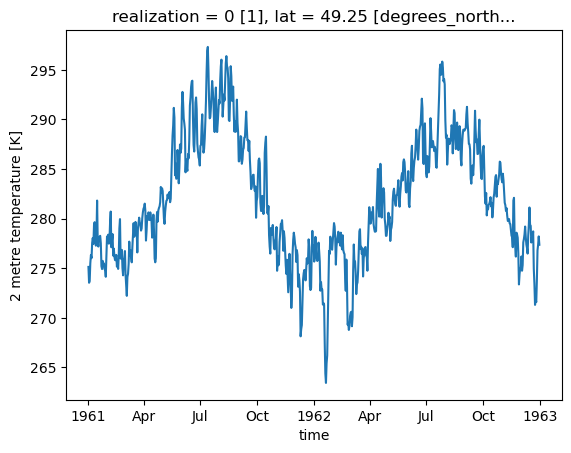

In [12]:
ds_two.plot()

### get baseline summer and winter temps to add to plot

In [13]:
# get baseline summer and winter temps
file_path_25 = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc'
file_path_75 = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_25 = xr.open_dataarray(file_path_25)
c_75 = xr.open_dataarray(file_path_75)
c_25_tmp = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
c_75_tmp = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")

### Plot Vancouver Time Series 
with thresholds

In [14]:
ds_two['DaysSince1961_01_01'] = (ds_two.time - np.datetime64('1961-01-01')).dt.days + 1

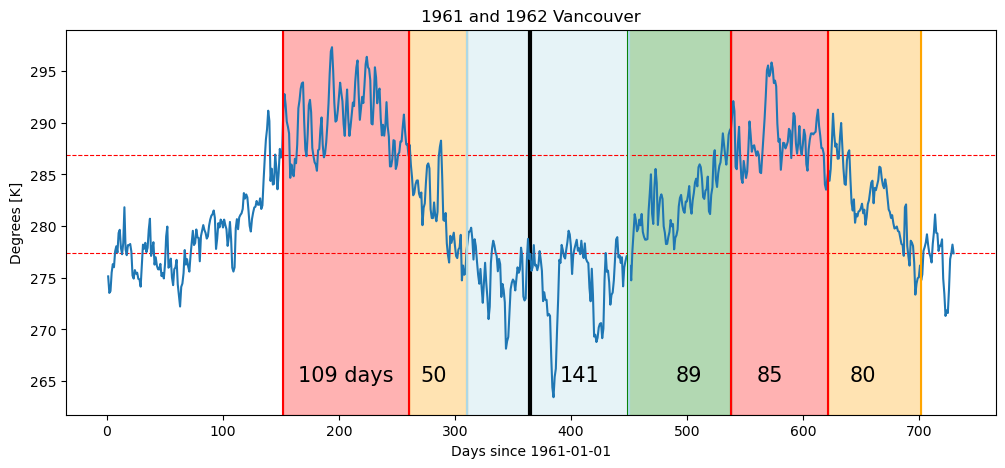

In [15]:
plt.figure(figsize=(12,5))

plt.axhline(c_25_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axhline(c_75_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axvline(365, color="black", linewidth=3)
plt.plot(ds_two.DaysSince1961_01_01, ds_two.values)
#plt.plot(ds_two.time, ds_two.values)

# put in the start end days that I calculated above for springs and autumns
# 1961 autumn
plt.axvline(ds_tmp.sel(time='1961').SummerEnd.values, color="orange")
plt.axvline(ds_tmp.sel(time='1961').WinterStart.values+183, color="orange")
plt.axvspan(ds_tmp.sel(time='1961').SummerEnd.values[0],
            (ds_tmp.sel(time='1961').WinterStart.values+183)[0], color='orange', alpha=0.3)

# 1962 spring
plt.axvline(ds_tmp.sel(time='1962').SummerStart.values + 365, color="green")
plt.axvline((ds_tmp.sel(time='1961').WinterEnd.values - 183)+365, color="green")
plt.axvspan(((ds_tmp.sel(time='1961').WinterEnd.values - 183)+365)[0],
            (ds_tmp.sel(time='1962').SummerStart.values + 365)[0], color='green', alpha=0.3)

# 1962 autumn following logic above
plt.axvline(ds_tmp.sel(time='1962').SummerEnd.values + 365, color="orange")
plt.axvline(ds_tmp.sel(time='1962').WinterStart.values+183 + 365, color="orange")
plt.axvspan(ds_tmp.sel(time='1962').SummerEnd.values[0] + 365,
            (ds_tmp.sel(time='1962').WinterStart.values+183)[0] + 365, color='orange', alpha=0.3)

# 1961 summer is all in 1961
plt.axvline(ds_tmp.sel(time='1961').SummerStart.values, color="red")
plt.axvline(ds_tmp.sel(time='1961').SummerEnd.values, color="red")
plt.axvspan(ds_tmp.sel(time='1961').SummerStart.values[0],
            ds_tmp.sel(time='1961').SummerEnd.values[0], color='red', alpha=0.3)

# 1962 summer is all in 1962
plt.axvline(ds_tmp.sel(time='1962').SummerStart.values + 365, color="red")
plt.axvline(ds_tmp.sel(time='1962').SummerEnd.values + 365, color="red")
plt.axvspan(ds_tmp.sel(time='1962').SummerStart.values[0] + 365,
            ds_tmp.sel(time='1962').SummerEnd.values[0] + 365, color='red', alpha=0.3)

# 1961 winter spans two calendar years
plt.axvline(ds_tmp.sel(time='1961').WinterStart.values + 183, color="lightblue")
plt.axvline(ds_tmp.sel(time='1961').WinterEnd.values + 183, color="lightblue")
plt.axvspan((ds_tmp.sel(time='1961').WinterStart.values + 183)[0],
            (ds_tmp.sel(time='1961').WinterEnd.values + 183)[0], color='lightblue', alpha=0.3)


# annotations
# summers and winter are easy
plt.annotate(str(int(ds_tmp.sel(time='1961').SummerLength.values[0]))+' days', xy=(165, 265), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp.sel(time='1962').SummerLength.values[0]), xy=(560, 265), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp.sel(time='1961').WinterLength.values[0]), xy=(390, 265), rotation=0, fontsize=15)

# spring 1962
plt.annotate(int((ds_tmp.sel(time='1962').SummerStart.values - (ds_tmp.sel(time='1961').WinterEnd.values - 183))[0]), xy=(490, 265), rotation=0, fontsize=15)

# autumn 1961
plt.annotate(int((ds_tmp.sel(time='1961').WinterStart.values+183)[0] - ds_tmp.sel(time='1961').SummerEnd.values[0]), xy=(270,265), rotation=0, fontsize=15)

# autumn 1962
plt.annotate(int((ds_tmp.sel(time='1962').WinterStart.values+183)[0] - ds_tmp.sel(time='1962').SummerEnd.values[0]), xy=(640,265), rotation=0, fontsize=15)

plt.title("1961 and 1962 Vancouver")
plt.xlabel("Days since 1961-01-01")
plt.ylabel("Degrees [K]")
plt.show()

In [16]:
ds_tmp.WinterLength.sel(time='1961').values

array([141.])

### test processing this NH grid square (Vancouver) for a couple of years

In [17]:
years = np.arange(1961,2026,1)

for year in years:
    # if it is 1961 then the spring needs to be NAN but we can get the autumn
    if year == 1961:
        springstart = np.nan
        springend = np.nan
        springlength = 0 #int(springend - springstart)
        autumnstart = ds_tmp.sel(time=str(year)).SummerEnd.values
        autumnend = ds_tmp.sel(time=str(year)).WinterStart.values+183
        autumnlength = int(autumnend[0] - autumnstart[0])
    else:
        springstart = ds_tmp.sel(time=str(year - 1)).WinterEnd.values - 183
        springend = ds_tmp.sel(time=str(year)).SummerStart.values
        springlength = int(springend[0] - springstart[0])
        autumnstart = ds_tmp.sel(time=str(year)).SummerEnd.values
        autumnend = ds_tmp.sel(time=str(year)).WinterStart.values+183
        autumnlength = int(autumnend[0] - autumnstart[0])
    print(str(year) + ": Spring [" + str(springlength) + "] Autumn [" + str(autumnlength) + "]")





1961: Spring [0] Autumn [50]
1962: Spring [89] Autumn [80]
1963: Spring [90] Autumn [51]
1964: Spring [69] Autumn [76]
1965: Spring [71] Autumn [81]
1966: Spring [110] Autumn [70]
1967: Spring [60] Autumn [54]
1968: Spring [102] Autumn [80]
1969: Spring [70] Autumn [93]
1970: Spring [106] Autumn [74]
1971: Spring [82] Autumn [61]
1972: Spring [82] Autumn [64]
1973: Spring [115] Autumn [70]
1974: Spring [106] Autumn [68]
1975: Spring [71] Autumn [58]
1976: Spring [95] Autumn [78]
1977: Spring [121] Autumn [60]
1978: Spring [109] Autumn [62]
1979: Spring [94] Autumn [68]
1980: Spring [105] Autumn [78]
1981: Spring [162] Autumn [73]
1982: Spring [69] Autumn [55]
1983: Spring [137] Autumn [69]
1984: Spring [128] Autumn [62]
1985: Spring [77] Autumn [45]
1986: Spring [134] Autumn [68]
1987: Spring [123] Autumn [63]
1988: Spring [107] Autumn [80]
1989: Spring [70] Autumn [91]
1990: Spring [92] Autumn [58]
1991: Spring [110] Autumn [74]
1992: Spring [144] Autumn [66]
1993: Spring [88] Autumn 

### Plot Sydney to get SH logic

In [18]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
c_25_tmp = c_25.sel(lat=input_lat, lon=input_lon, method="nearest")
c_75_tmp = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
ds_two_syd = xr.concat([curr, nxt], dim="time")
ds_two_syd['DaysSince1961_01_01'] = (ds_two_syd.time - np.datetime64('1961-01-01')).dt.days + 1

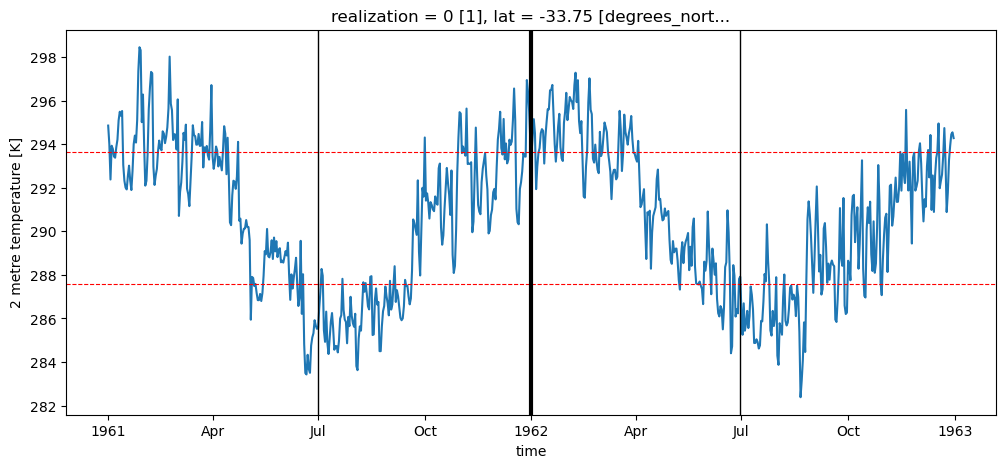

In [19]:
plt.figure(figsize=(12,5))
ds_two_syd.plot()
plt.axhline(c_25_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axhline(c_75_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axvline(np.datetime64('1962-01-01'), color="black", linewidth=3)
plt.axvline(np.datetime64('1962-06-30'), color="black", linewidth=1)
plt.axvline(np.datetime64('1961-07-01'), color="black", linewidth=1)

In [20]:
syd_sum = ds_summ.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_win = ds_wint.sel(lat=input_lat, lon=input_lon, method="nearest")

In [21]:
ds_tmp_syd = syd_sum.merge(syd_win)
ds_tmp_syd

<xarray.Dataset> Size: 9kB
Dimensions:         (time: 65)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat             float64 8B -33.75
    lon             float64 8B 151.2
Data variables: (12/18)
    SummerStart     (time) float64 520B ...
    SummerEnd       (time) float64 520B ...
    SummerTmax      (time) float64 520B ...
    SummerHeat      (time) float64 520B ...
    SummerLength    (time) float64 520B ...
    SummerlikeDays  (time) float64 520B ...
    ...              ...
    WinterTmax      (time) float64 520B ...
    WinterCold      (time) float64 520B ...
    WinterLength    (time) float64 520B ...
    WinterlikeDays  (time) float64 520B ...
    WinterRMSE      (time) float64 520B ...
    WinterMeanT     (time) float64 520B ...

#### SH logic is flipped from NH
- 1961 has no autumn but has a spring, because the SH summer starts on July 1 1961 in my processing

In [38]:
# Spring (1961)
# the SH spring is all in the same calendar year (which was defined relative to July 1 for summer data)
ds_tmp_syd.sel(time='1961').WinterEnd.values, ds_tmp_syd.sel(time='1961').SummerStart.values

(array([248.]), array([177.]))

In [40]:
ds_tmp_syd.sel(time='1961').WinterEnd.values, ds_tmp_syd.sel(time='1961').SummerStart.values + 183, ds_tmp_syd.sel(time='1961').SummerStart.values + 183 - (ds_tmp_syd.sel(time='1961').WinterEnd.values)

(array([248.]), array([360.]), array([112.]))

In [63]:
# Autumn (1962)
# Note: in the SH the summer end of 1961 is actually in calendar year 1962 so will need an offset of 183
ds_tmp_syd.sel(time='1962').WinterStart.values, ds_tmp_syd.sel(time='1961').SummerEnd.values

(array([158.]), array([258.]))

In [69]:
ds_tmp_syd.sel(time='1962').WinterStart.values, ds_tmp_syd.sel(time='1961').SummerEnd.values-183, ds_tmp_syd.sel(time='1962').WinterStart.values - (ds_tmp_syd.sel(time='1961').SummerEnd.values-183) 

(array([158.]), array([75.]), array([83.]))

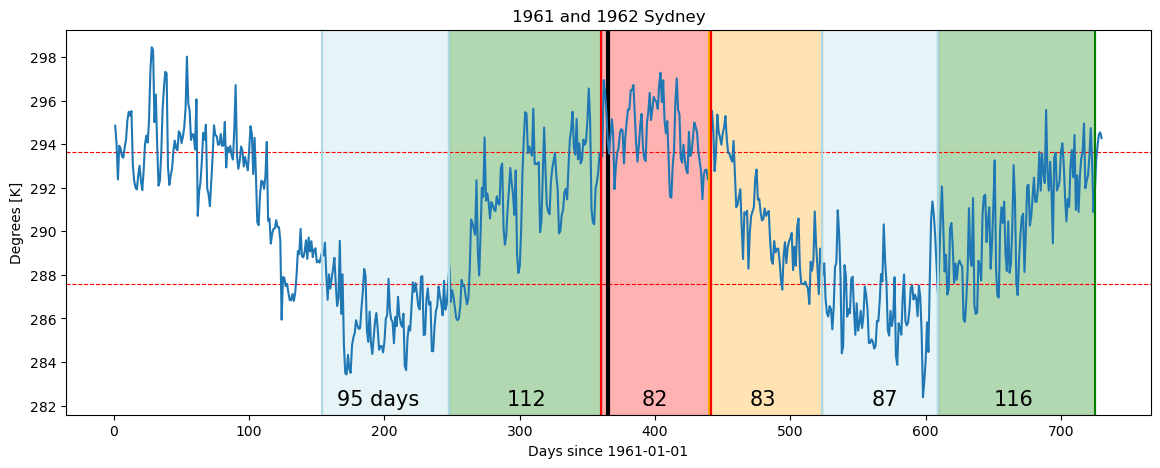

In [22]:
plt.figure(figsize=(14,5))

plt.axhline(c_25_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axhline(c_75_tmp.values, color="red", linewidth=0.8, linestyle="dashed") 
plt.axvline(365, color="black", linewidth=3)
plt.plot(ds_two_syd.DaysSince1961_01_01, ds_two_syd.values)
#plt.plot(ds_two.time, ds_two.values)

# put in the start end days that I calculated above for springs and autumns
# 1961 Spring
plt.axvline(ds_tmp_syd.sel(time='1961').WinterEnd.values, color="green")
plt.axvline(ds_tmp_syd.sel(time='1961').SummerStart.values + 183, color="green")
plt.axvspan(ds_tmp_syd.sel(time='1961').WinterEnd.values[0],
            (ds_tmp_syd.sel(time='1961').SummerStart.values + 183)[0], color='green', alpha=0.3)

# 1962 spring
plt.axvline(ds_tmp_syd.sel(time='1962').WinterEnd.values + 365, color="green")
plt.axvline((ds_tmp_syd.sel(time='1962').SummerStart.values + 183)+365, color="green")
plt.axvspan((ds_tmp_syd.sel(time='1962').WinterEnd.values[0]+365),
            (ds_tmp_syd.sel(time='1962').SummerStart.values[0]+ 183 + 365), color='green', alpha=0.3)

# 1962 autumn following logic above
plt.axvline((ds_tmp_syd.sel(time='1961').SummerEnd.values-183) + 365, color="orange")
plt.axvline(ds_tmp_syd.sel(time='1962').WinterStart.values + 365, color="orange")
plt.axvspan((ds_tmp_syd.sel(time='1961').SummerEnd.values[0]-183) + 365,
            (ds_tmp_syd.sel(time='1962').WinterStart.values)[0] + 365, color='orange', alpha=0.3)

# 1961 winter is all in 1961
plt.axvline(ds_tmp_syd.sel(time='1961').WinterStart.values, color="lightblue")
plt.axvline(ds_tmp_syd.sel(time='1961').WinterEnd.values, color="lightblue")
plt.axvspan(ds_tmp_syd.sel(time='1961').WinterStart.values[0],
            ds_tmp_syd.sel(time='1961').WinterEnd.values[0], color='lightblue', alpha=0.3)

# 1962 winter is all in 1962
plt.axvline(ds_tmp_syd.sel(time='1962').WinterStart.values + 365, color="lightblue")
plt.axvline(ds_tmp_syd.sel(time='1962').WinterEnd.values + 365, color="lightblue")
plt.axvspan(ds_tmp_syd.sel(time='1962').WinterStart.values[0] + 365,
            ds_tmp_syd.sel(time='1962').WinterEnd.values[0] + 365, color='lightblue', alpha=0.3)

# 1961 summer spans two calendar years
plt.axvline(ds_tmp_syd.sel(time='1961').SummerStart.values + 183, color="red")
plt.axvline(ds_tmp_syd.sel(time='1961').SummerEnd.values + 183, color="red")
plt.axvspan((ds_tmp_syd.sel(time='1961').SummerStart.values + 183)[0],
            (ds_tmp_syd.sel(time='1961').SummerEnd.values + 183)[0], color='red', alpha=0.3)


# annotations
# summers and winter are easy
plt.annotate(str(int(ds_tmp_syd.sel(time='1961').WinterLength.values[0]))+' days', xy=(165, 282), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp_syd.sel(time='1962').WinterLength.values[0]), xy=(560, 282), rotation=0, fontsize=15)
plt.annotate(int(ds_tmp_syd.sel(time='1961').SummerLength.values[0]), xy=(390, 282), rotation=0, fontsize=15)

# spring 1961
plt.annotate(int( (ds_tmp_syd.sel(time='1961').SummerStart.values + 183)[0] - (ds_tmp_syd.sel(time='1961').WinterEnd.values[0])), xy=(290, 282), rotation=0, fontsize=15)

# spring 1962
plt.annotate(int( (ds_tmp_syd.sel(time='1962').SummerStart.values + 183)[0] - (ds_tmp_syd.sel(time='1962').WinterEnd.values[0])), xy=(650, 282), rotation=0, fontsize=15)

# autumn 1962
plt.annotate(int((ds_tmp_syd.sel(time='1962').WinterStart.values)[0] - (ds_tmp_syd.sel(time='1961').SummerEnd.values[0]-183)), xy=(470,282), rotation=0, fontsize=15)

#plt.grid()
plt.title("1961 and 1962 Sydney")
plt.xlabel("Days since 1961-01-01")
plt.ylabel("Degrees [K]")
plt.show()

In [23]:
ds_tmp_syd.sel(time='1961').SummerLength.values

array([82.])

### test processing this SH grid square (Sydney) for a couple of years

In [24]:
years = np.arange(1961,2026,1)

for year in years:
    # if it is 1961 then the Autumn needs to be NAN but we can get the spring
    if year == 1961:
        springstart = (ds_tmp_syd.sel(time=str(year)).WinterEnd.values[0])
        springend = (ds_tmp_syd.sel(time=str(year)).SummerStart.values + 183)[0]
        springlength = int(springend - springstart)
        autumnstart = np.nan
        autumnend = np.nan
        autumnlength = 0 #int(autumnend[0] - autumnstart[0])
        summerlength = (ds_tmp_syd.sel(time=str(year)).SummerLength.values)[0]
        winterlength = (ds_tmp_syd.sel(time=str(year)).WinterLength.values)[0]
        total = springlength + summerlength + autumnlength + winterlength
    else:
        springstart = (ds_tmp_syd.sel(time=str(year)).WinterEnd.values[0])
        springend = (ds_tmp_syd.sel(time=str(year)).SummerStart.values + 183)[0]
        springlength = int(springend - springstart)
        autumnstart = (ds_tmp_syd.sel(time=str(year-1)).SummerEnd.values[0]-183)
        autumnend = (ds_tmp_syd.sel(time=str(year)).WinterStart.values)[0]
        autumnlength = int(autumnend - autumnstart)
        summerlength = (ds_tmp_syd.sel(time=str(year)).SummerLength.values)[0]
        winterlength = (ds_tmp_syd.sel(time=str(year)).WinterLength.values)[0]
        total = springlength + summerlength + autumnlength + winterlength
    print(str(year) + ": Winter ["+ str(winterlength)+"] "+ "Spring [" + str(springlength) +"] Summer ["+str(summerlength)+"] "+"Autumn [" + str(autumnlength) + "]" + " Total = "+str(total))





1961: Winter [95.0] Spring [112] Summer [82.0] Autumn [0] Total = 289.0
1962: Winter [87.0] Spring [116] Summer [92.0] Autumn [83] Total = 378.0
1963: Winter [92.0] Spring [104] Summer [98.0] Autumn [72] Total = 366.0
1964: Winter [81.0] Spring [158] Summer [54.0] Autumn [71] Total = 364.0
1965: Winter [86.0] Spring [124] Summer [86.0] Autumn [73] Total = 369.0
1966: Winter [110.0] Spring [90] Summer [83.0] Autumn [69] Total = 352.0
1967: Winter [78.0] Spring [124] Summer [94.0] Autumn [107] Total = 403.0
1968: Winter [96.0] Spring [103] Summer [108.0] Autumn [48] Total = 355.0
1969: Winter [103.0] Spring [104] Summer [94.0] Autumn [62] Total = 363.0
1970: Winter [109.0] Spring [102] Summer [98.0] Autumn [63] Total = 372.0
1971: Winter [90.0] Spring [130] Summer [61.0] Autumn [65] Total = 346.0
1972: Winter [82.0] Spring [113] Summer [110.0] Autumn [87] Total = 392.0
1973: Winter [78.0] Spring [104] Summer [114.0] Autumn [74] Total = 370.0
1974: Winter [105.0] Spring [97] Summer [82.0]

## Process all years, all season lengths - add spring and autumn length

In [25]:
ds_seasons = ds_wint.merge(ds_summ)
ds_seasons = ds_seasons.drop_vars(['WinterTmax','WinterCold','WinterlikeDays','WinterRMSE','WinterMeanT','lsm','SummerTmax','SummerHeat','SummerlikeDays','SummerRMSE','SummerMeanT'])
ds_seasons

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    Coastal       (time, lat, lon) bool 67MB False False False ... False False
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...

In [26]:
# set spring and autumn lengths to zero initially but ensure they have coordinates
ds_seasons['SpringLength'] = ds_seasons.SummerLength - ds_seasons.SummerLength
ds_seasons['AutumnLength'] = ds_seasons.SummerLength - ds_seasons.SummerLength
ds_seasons

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    Coastal       (time, lat, lon) bool 67MB False False False ... False False
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...
    SpringLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

### split by hemisphere since we process each differently

In [27]:
# split by hemisphere since we process each differently
nh = ds_seasons.sel(lat=slice(0,90))
sh = ds_seasons.sel(lat=slice(-90,-0.25))

In [28]:
ds_seasons['SpringLength'].sel(lat=slice(0,90))

<xarray.DataArray 'SpringLength' (time: 65, lat: 361, lon: 1440)> Size: 270MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(65, 361, 1440))
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01
  * lat      (lat) float64 3kB 0.0 0.25 0.5 0.75 1.0 ... 89.25 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

### SH Springs are easy

In [29]:
# SH springs are easy
# springstart = (ds_tmp_syd.sel(time=str(year)).WinterEnd.values[0])
# springend = (ds_tmp_syd.sel(time=str(year)).SummerStart.values + 183)[0]
# springlength = int(springend - springstart)
sh['SpringLength'] = (sh.SummerStart + 183) - sh.WinterEnd
sh

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 65, lat: 360, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 3kB -90.0 -89.75 -89.5 ... -0.75 -0.5 -0.25
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 270MB ...
    WinterEnd     (time, lat, lon) float64 270MB ...
    WinterLength  (time, lat, lon) float64 270MB ...
    Coastal       (time, lat, lon) bool 34MB False False False ... False False
    SummerStart   (time, lat, lon) float64 270MB 135.0 135.0 135.0 ... 1.0 1.0
    SummerEnd     (time, lat, lon) float64 270MB ...
    SummerLength  (time, lat, lon) float64 270MB ...
    SpringLength  (time, lat, lon) float64 270MB 193.0 193.0 ... 128.0 129.0
    AutumnLength  (time, lat, lon) float64 270MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [30]:
# check Sydney 1961 and 1962 to confirm
syd_lat = -33 - 52/60 - 4/3600
syd_lon = 151.25
sh.SpringLength.sel(time='1961', lat=syd_lat, lon=syd_lon, method="nearest"), sh.SpringLength.sel(time='1962', lat=syd_lat, lon=syd_lon, method="nearest")

(<xarray.DataArray 'SpringLength' ()> Size: 8B
 array(112.)
 Coordinates:
     lat      float64 8B -33.75
     lon      float64 8B 151.2
     time     datetime64[ns] 8B 1961-01-01,
 <xarray.DataArray 'SpringLength' ()> Size: 8B
 array(116.)
 Coordinates:
     lat      float64 8B -33.75
     lon      float64 8B 151.2
     time     datetime64[ns] 8B 1962-01-01)

### SH Autumns are more tricky

In [31]:
# index by dimension coordinate labels
# da.loc[dict(time=slice("2000-01-01", "2000-01-02"))]

sh.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time='1961-01-01')]['AutumnLength']

<xarray.DataArray 'AutumnLength' (lat: 360, lon: 1440)> Size: 4MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(360, 1440))
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.75 -89.5 -89.25 ... -0.75 -0.5 -0.25
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    time     datetime64[ns] 8B 1961-01-01

In [184]:
# SH autumns have to start w/ 1962
# autumnstart = (ds_tmp_syd.sel(time=str(year-1)).SummerEnd.values[0]-183)
# autumnend = (ds_tmp_syd.sel(time=str(year)).WinterStart.values)[0]
# autumnlength = int(autumnend - autumnstart)
# proc_yrs = np.arange(1962, 2025)
# for yr in proc_yrs:
#     sh.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time=str(yr))]['AutumnLength'] = sh.WinterStart.sel(time = str(yr)).values - (sh.SummerEnd.sel(time = str(yr - 1)) - 183).values

# sh



In [32]:
sh.WinterStart.sel(time = '1962').values - (sh.SummerEnd.sel(time = '1961') - 183).values

array([[[190., 190., 190., ..., 190., 190., 190.],
        [186., 186., 186., ..., 186., 186., 186.],
        [181., 181., 181., ..., 181., 181., 181.],
        ...,
        [229., 229., 229., ..., 229., 229., 229.],
        [230., 230., 230., ..., 231., 230., 231.],
        [232., 231., 232., ..., 231., 231., 232.]]], shape=(1, 360, 1440))

#### solution? - check out https://docs.xarray.dev/en/stable/user-guide/indexing.html#assigning-values-with-indexing and try the "where" syntax

#### Ooh, found something that might work - have to make a data array for the autumn length values instead of working with the full dataset

In [33]:
sh_autumn = sh.AutumnLength.copy(deep=True)
# sh_autumn.loc[dict(lat=-90, lon=-180, time='1962')] = 1.0
# sh_autumn.loc[dict(lat=-90, lon=-180, time='1962')]

In [34]:
proc_yrs = np.arange(1962, 2026)
for yr in proc_yrs:
    sh_autumn.loc[dict(lat=slice(-90,-0.25), lon=slice(-180,180), time=str(yr))] = sh.WinterStart.sel(time = str(yr)).values - (sh.SummerEnd.sel(time = str(yr - 1)) - 183).values

sh_autumn

<xarray.DataArray 'AutumnLength' (time: 65, lat: 360, lon: 1440)> Size: 270MB
array([[[   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.]],

       [[ 190.,  190.,  190., ...,  190.,  190.,  190.],
        [ 186.,  186.,  186., ...,  186.,  186.,  186.],
        [ 181.,  181.,  181., ...,  181.,  181.,  181.],
        ...,
        [ 229.,  229.,  229., ...,  229.,  229.,  229.],
        [ 230.,  230.,  230., ...,  231.,  230.,  231.],
        [ 232.,  231.,  232., ...,  231.,  231.,  232.]],

       [[ 143.,  143.,  143., ...,  143.,  143.,  143.],
        [ 141.,  141.,  141., ...,  141.,  141.,  141.],
        [ 140.,  140.,  140., ...,  140.,  140.,  140.],
        ...,
...
        [-124., -125., -126., ..., -121., -122., -123.],
        [-124., -125., -127., ..., -122., -123., -124.],
        [-126., -126., -127., ..., -123., -124., -125.]],

       [[ 106.,  106.,  106., ...,  106.,  106.,  106.],
        [ 106.,  106.,  106., ...,  106.,  106.,  106.],
        [ 106.,  106.,  106., ...,  106.,  106.,  106.],
        ...,
        [ 136.,  137.,  137., ...,  136.,  136.,  136.],
        [ 138.,  137.,  136., ...,  137.,  137.,  138.],
        [ 138.,  138.,  137., ...,  138.,  138.,  138.]],

       [[ 142.,  142.,  142., ...,  142.,  142.,  142.],
        [ 146.,  146.,  146., ...,  145.,  146.,  146.],
        [ 150.,  150.,  150., ...,  150.,  150.,  150.],
        ...,
        [  62.,   60.,   56., ...,   61.,   61.,   62.],
        [  57.,   55.,   52., ...,   53.,   54.,   55.],
        [  51.,   51.,   49., ...,   50.,   50.,   51.]]],
      shape=(65, 360, 1440))
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01
  * lat      (lat) float64 3kB -90.0 -89.75 -89.5 -89.25 ... -0.75 -0.5 -0.25
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

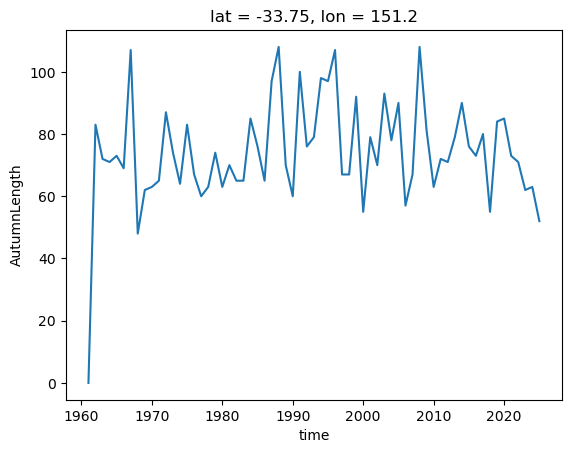

In [35]:
# autumn length for Sydney
sh_autumn.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot()

#### OK, have SH Autumns

### NH Autumns are easy

In [36]:
# NH autumns are easy
# autumnstart = ds_tmp.sel(time=str(year)).SummerEnd.values
# autumnend = ds_tmp.sel(time=str(year)).WinterStart.values+183
# autumnlength = int(autumnend[0] - autumnstart[0])
nh['AutumnLength'] = (nh.WinterStart + 183) - nh.SummerEnd
nh

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 65, lat: 361, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 3kB 0.0 0.25 0.5 0.75 ... 89.25 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 270MB 174.0 175.0 ... 219.0 219.0
    WinterEnd     (time, lat, lon) float64 270MB ...
    WinterLength  (time, lat, lon) float64 270MB ...
    Coastal       (time, lat, lon) bool 34MB False False False ... False False
    SummerStart   (time, lat, lon) float64 270MB ...
    SummerEnd     (time, lat, lon) float64 270MB ...
    SummerLength  (time, lat, lon) float64 270MB ...
    SpringLength  (time, lat, lon) float64 270MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 270MB 357.0 358.0 ... 150.0 150.0

### NH Springs are trickier

In [37]:
nh_spring = nh.SpringLength.copy(deep=True)
nh_spring

<xarray.DataArray 'SpringLength' (time: 65, lat: 361, lon: 1440)> Size: 270MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(65, 361, 1440))
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01
  * lat      (lat) float64 3kB 0.0 0.25 0.5 0.75 1.0 ... 89.25 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

In [38]:
proc_yrs = np.arange(1962, 2026)
for yr in proc_yrs:
    nh_spring.loc[dict(lat=slice(0,90), lon=slice(-180,180), time=str(yr))] = nh.SummerStart.sel(time = str(yr)).values - (nh.WinterEnd.sel(time = str(yr - 1)) - 183).values

nh_spring

<xarray.DataArray 'SpringLength' (time: 65, lat: 361, lon: 1440)> Size: 270MB
array([[[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  9.,   8.,   8., ...,  12.,  12.,  11.],
        [  4.,   1.,  -1., ...,  12.,   9.,   7.],
        [ -7., -13., -37., ...,   9.,   5.,  -1.],
        ...,
        [ 76.,  76.,  76., ...,  76.,  76.,  76.],
        [ 76.,  76.,  76., ...,  76.,  76.,  76.],
        [ 76.,  76.,  76., ...,  76.,  76.,  76.]],

       [[154., 153., 154., ..., 158., 156., 155.],
        [154., 155., 155., ..., 159., 157., 156.],
        [157., 157., 157., ..., 160., 159., 158.],
        ...,
...
        ...,
        [113., 113., 113., ..., 113., 113., 113.],
        [110., 110., 110., ..., 110., 110., 110.],
        [ 85.,  85.,  85., ...,  85.,  85.,  85.]],

       [[-83., -84., -84., ..., 138., 138., -83.],
        [-84., -84., -84., ..., 138., -83., -83.],
        [-84., -84., -84., ..., 138., -84., -84.],
        ...,
        [ 97.,  97.,  97., ...,  97.,  97.,  97.],
        [ 97.,  97.,  97., ...,  97.,  97.,  97.],
        [ 96.,  96.,  96., ...,  96.,  96.,  96.]],

       [[ 54.,  53.,  52., ...,  56.,  56.,  55.],
        [ 54.,  53.,  53., ...,  57.,  56.,  55.],
        [ 56.,  54.,  54., ...,  59.,  58.,  57.],
        ...,
        [136., 136., 136., ..., 136., 136., 136.],
        [137., 137., 137., ..., 137., 137., 137.],
        [137., 137., 137., ..., 137., 137., 137.]]], shape=(65, 361, 1440))
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01
  * lat      (lat) float64 3kB 0.0 0.25 0.5 0.75 1.0 ... 89.25 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

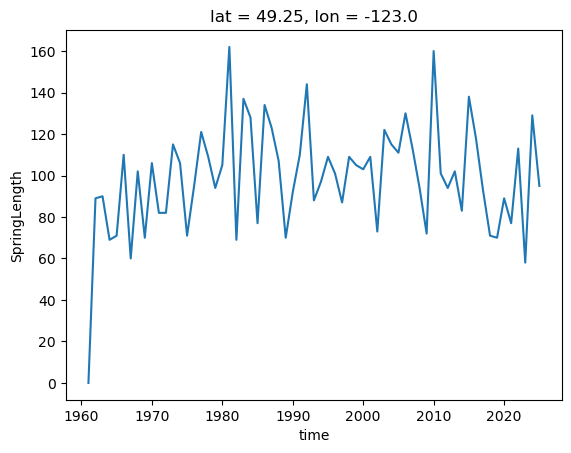

In [39]:
# spring length for Vancouver
van_lat = 49.246
van_lon = -123.116
nh_spring.sel(lat=van_lat, lon=van_lon, method='nearest').plot()

In [40]:
ds_seasons

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    Coastal       (time, lat, lon) bool 67MB False False False ... False False
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...
    SpringLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    AutumnLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

### Now merge all the data back together to write it out

In [41]:
nh['SpringLength'] = nh_spring

# check van
nh.sel(lat=van_lat, lon=van_lon, method='nearest')

<xarray.Dataset> Size: 5kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat           float64 8B 49.25
    lon           float64 8B -123.0
Data variables:
    WinterStart   (time) float64 520B 127.0 154.0 142.0 ... 184.0 175.0 210.0
    WinterEnd     (time) float64 520B ...
    WinterLength  (time) float64 520B ...
    Coastal       (time) bool 65B True True True True ... True True True True
    SummerStart   (time) float64 520B ...
    SummerEnd     (time) float64 520B ...
    SummerLength  (time) float64 520B ...
    SpringLength  (time) float64 520B 0.0 89.0 90.0 69.0 ... 58.0 129.0 95.0
    AutumnLength  (time) float64 520B 50.0 80.0 51.0 76.0 ... 99.0 95.0 126.0

In [42]:
syd_lat = -33 - 52/60 - 4/3600
syd_lon = 151.25

sh['AutumnLength'] = sh_autumn

# check Sydney
sh.sel(lat=syd_lat, lon=syd_lon, method='nearest')

<xarray.Dataset> Size: 5kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat           float64 8B -33.75
    lon           float64 8B 151.2
Data variables:
    WinterStart   (time) float64 520B ...
    WinterEnd     (time) float64 520B ...
    WinterLength  (time) float64 520B ...
    Coastal       (time) bool 65B True True True True ... True True True True
    SummerStart   (time) float64 520B 177.0 177.0 169.0 ... 146.0 141.0 139.0
    SummerEnd     (time) float64 520B ...
    SummerLength  (time) float64 520B ...
    SpringLength  (time) float64 520B 112.0 116.0 104.0 ... 121.0 113.0 98.0
    AutumnLength  (time) float64 520B 0.0 83.0 72.0 71.0 ... 71.0 62.0 63.0 52.0

In [43]:
combined = nh.merge(sh)
combined

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 65)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart   (time, lat, lon) float64 540MB 88.0 88.0 88.0 ... 219.0 219.0
    WinterEnd     (time, lat, lon) float64 540MB 125.0 125.0 ... 219.0 219.0
    WinterLength  (time, lat, lon) float64 540MB 38.0 38.0 38.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerStart   (time, lat, lon) float64 540MB 135.0 135.0 ... 150.0 150.0
    SummerEnd     (time, lat, lon) float64 540MB 224.0 224.0 ... 252.0 252.0
    SummerLength  (time, lat, lon) float64 540MB 90.0 90.0 90.0 ... 103.0 103.0
    SpringLength  (time, lat, lon) float64 540MB 193.0 193.0 ... 137.0 137.0
    AutumnLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 ... 150.0 150.0

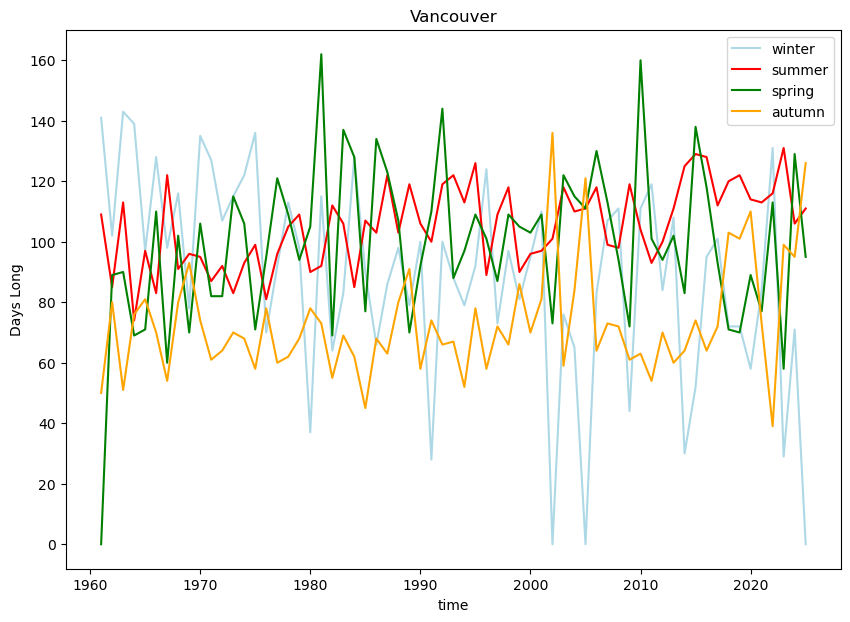

In [44]:
# plot Van seasons
plt.figure(figsize=(10,7))
combined.WinterLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="lightblue", label="winter")
combined.SummerLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="red", label="summer")
combined.SpringLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="green", label="spring")
combined.AutumnLength.sel(lat=van_lat, lon=van_lon, method='nearest').plot(color="orange", label="autumn")
plt.ylabel("Days Long")
plt.title("Vancouver")
plt.legend()
plt.show()

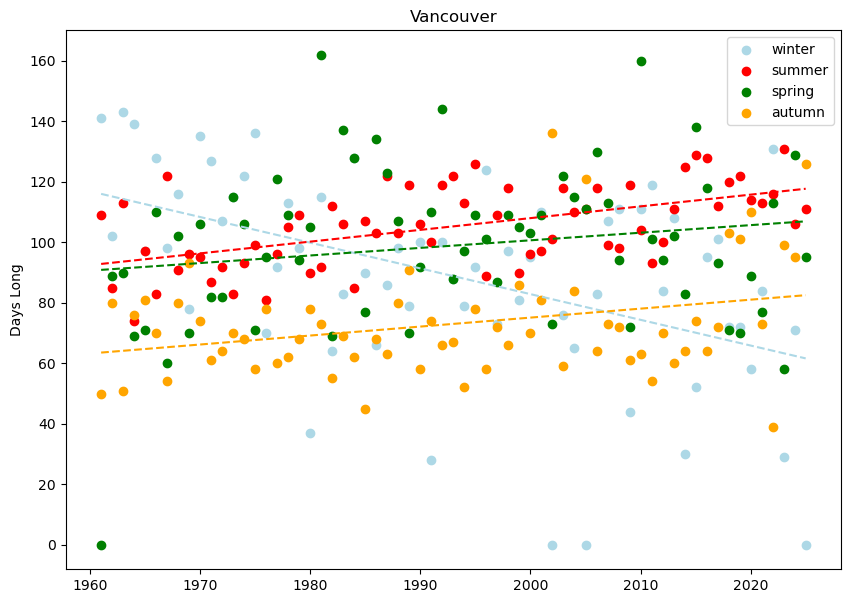

In [45]:
# plot Vancouver seasons as scatter plot with linear fits
van_data = combined.sel(lat=van_lat, lon=van_lon, method='nearest')
van_data = van_data.sel(time=slice('1961','2025'))

plt.figure(figsize=(10,7))
x = van_data.time.dt.year.values
y = van_data.WinterLength.values
plt.scatter(x=x, y=y, color="lightblue", label="winter")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="lightblue", linestyle="dashed")

y = van_data.SummerLength.values
plt.scatter(x=x, y=y, color="red", label="summer")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="red", linestyle="dashed")

y = van_data.SpringLength.values
plt.scatter(x=x, y=y, color="green", label="spring")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="green", linestyle="dashed")

y = van_data.AutumnLength.values
plt.scatter(x=x, y=y, color="orange", label="autumn")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="orange", linestyle="dashed")
plt.ylabel("Days Long")
plt.title("Vancouver")
plt.legend()
plt.show()

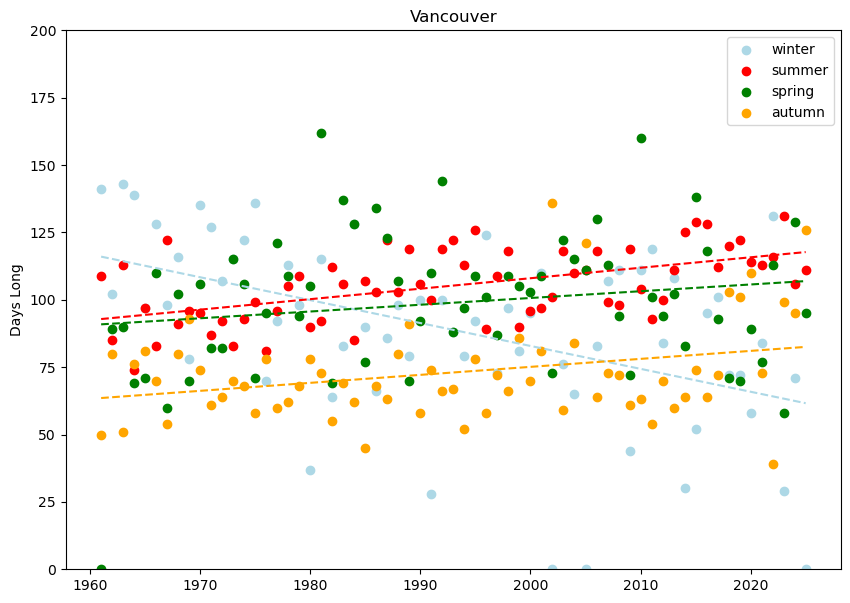

In [46]:
# same but narrow y range
# plot Vancouver seasons as scatter plot with linear fits
van_data = combined.sel(lat=van_lat, lon=van_lon, method='nearest')
van_data = van_data.sel(time=slice('1961','2025'))

plt.figure(figsize=(10,7))
x = van_data.time.dt.year.values
y = van_data.WinterLength.values
plt.scatter(x=x, y=y, color="lightblue", label="winter")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="lightblue", linestyle="dashed")

y = van_data.SummerLength.values
plt.scatter(x=x, y=y, color="red", label="summer")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="red", linestyle="dashed")

y = van_data.SpringLength.values
plt.scatter(x=x, y=y, color="green", label="spring")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="green", linestyle="dashed")

y = van_data.AutumnLength.values
plt.scatter(x=x, y=y, color="orange", label="autumn")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="orange", linestyle="dashed")
plt.ylabel("Days Long")
plt.ylim(0,200)
plt.title("Vancouver")
plt.legend()
plt.show()

In [47]:
combined.sel(lat=syd_lat, lon=syd_lon, method='nearest')

<xarray.Dataset> Size: 5kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
    lat           float64 8B -33.75
    lon           float64 8B 151.2
Data variables:
    WinterStart   (time) float64 520B 154.0 158.0 157.0 ... 152.0 155.0 161.0
    WinterEnd     (time) float64 520B 248.0 244.0 248.0 ... 208.0 211.0 224.0
    WinterLength  (time) float64 520B 95.0 87.0 92.0 81.0 ... 57.0 57.0 64.0
    Coastal       (time) float64 520B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    SummerStart   (time) float64 520B 177.0 177.0 169.0 ... 146.0 141.0 139.0
    SummerEnd     (time) float64 520B 258.0 268.0 266.0 ... 275.0 292.0 276.0
    SummerLength  (time) float64 520B 82.0 92.0 98.0 54.0 ... 130.0 152.0 138.0
    SpringLength  (time) float64 520B 112.0 116.0 104.0 ... 121.0 113.0 98.0
    AutumnLength  (time) float64 520B 0.0 83.0 72.0 71.0 ... 71.0 62.0 63.0 52.0

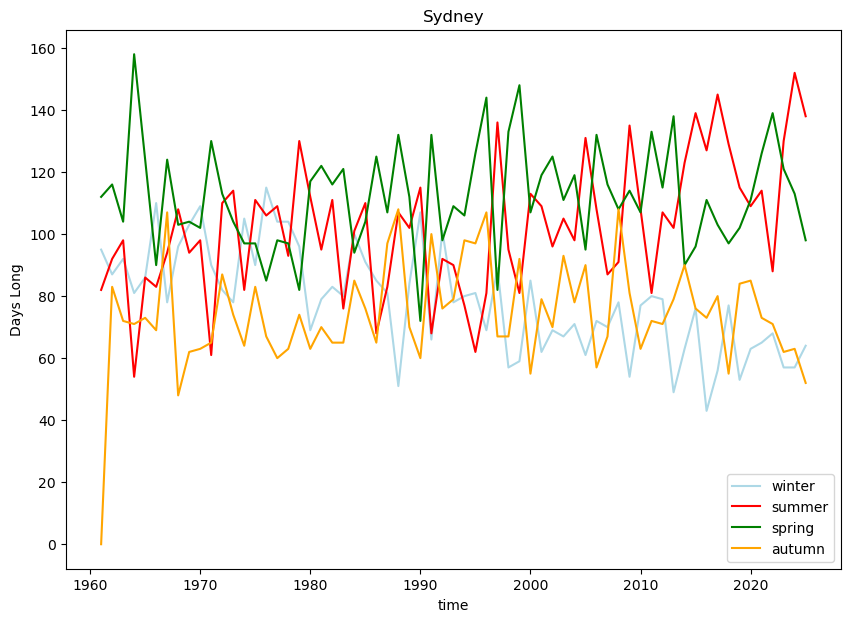

In [48]:
# plot Sydney seasons but scatter plot
plt.figure(figsize=(10,7))
combined.WinterLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="lightblue", label="winter")
combined.SummerLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="red", label="summer")
combined.SpringLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="green", label="spring")
combined.AutumnLength.sel(lat=syd_lat, lon=syd_lon, method='nearest').plot(color="orange", label="autumn")
plt.ylabel("Days Long")
plt.title("Sydney")
plt.legend()
plt.show()

### Write it out

In [49]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/1961-2025_ALL_season_stats.nc'
combined.to_netcdf(output_path)

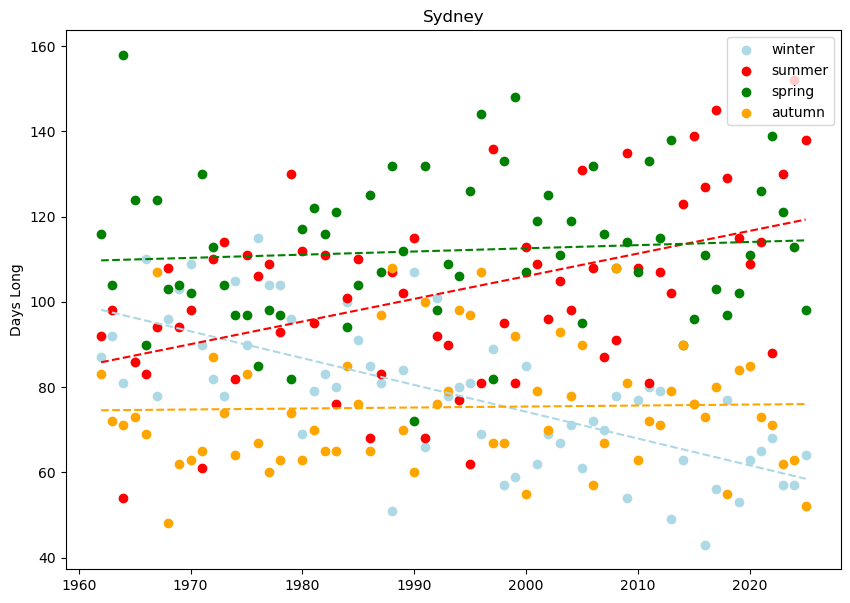

In [50]:

# plot Sydney seasons as scatter plot with linear fits
syd_data = combined.sel(lat=syd_lat, lon=syd_lon, method='nearest')
syd_data = syd_data.sel(time=slice('1962','2025'))

plt.figure(figsize=(10,7))
x = syd_data.time.dt.year.values
y = syd_data.WinterLength.values
plt.scatter(x=x, y=y, color="lightblue", label="winter")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="lightblue", linestyle="dashed")

y = syd_data.SummerLength.values
plt.scatter(x=x, y=y, color="red", label="summer")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="red", linestyle="dashed")

y = syd_data.SpringLength.values
plt.scatter(x=x, y=y, color="green", label="spring")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="green", linestyle="dashed")

y = syd_data.AutumnLength.values
plt.scatter(x=x, y=y, color="orange", label="autumn")
a, b = np.polyfit(x, y, 1)
plt.plot(x, a*x+b, color="orange", linestyle="dashed")
plt.ylabel("Days Long")
plt.title("Sydney")
plt.legend()
plt.show()

In [51]:
syd_data.time.dt.year.values, syd_data.AutumnLength.values

(array([1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
        1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983,
        1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
        1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
        2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
        2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]),
 array([ 83.,  72.,  71.,  73.,  69., 107.,  48.,  62.,  63.,  65.,  87.,
         74.,  64.,  83.,  67.,  60.,  63.,  74.,  63.,  70.,  65.,  65.,
         85.,  76.,  65.,  97., 108.,  70.,  60., 100.,  76.,  79.,  98.,
         97., 107.,  67.,  67.,  92.,  55.,  79.,  70.,  93.,  78.,  90.,
         57.,  67., 108.,  81.,  63.,  72.,  71.,  79.,  90.,  76.,  73.,
         80.,  55.,  84.,  85.,  73.,  71.,  62.,  63.,  52.]))

### Make a "warming stripes" like visual

In [279]:
x, y

(array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
        1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
        1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
        1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
        2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
        2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]),
 array([ 50.,  80.,  51.,  76.,  81.,  70.,  54.,  80.,  93.,  74.,  61.,
         64.,  70.,  68.,  58.,  78.,  60.,  62.,  68.,  78.,  73.,  55.,
         69.,  62.,  45.,  68.,  63.,  80.,  91.,  58.,  74.,  66.,  67.,
         52.,  78.,  58.,  72.,  66.,  86.,  70.,  81., -76.,  59.,  84.,
        -80.,  64.,  73.,  72.,  61.,  63.,  54.,  70.,  60.,  64.,  74.,
         64.,  72., 103., 101., 110.,  73.,  39.,  99.,  95., -84.]))

<BarContainer object of 64 artists>

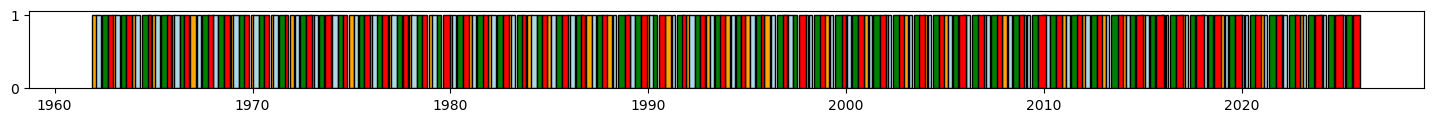

In [52]:
x = syd_data.time.dt.year.values
AL = syd_data.AutumnLength.values/365.0
WL = syd_data.WinterLength.values/365.0
SpL = syd_data.SpringLength.values/365.0
SL = syd_data.SummerLength.values/365.0

# bar positions
r = np.arange(min(x), max(x)+1)
r2 = r + AL
r3 = r2 + SpL
r4 = r3 + SL

plt.figure(figsize=(18,1))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html
plt.bar(
    r,
    height=1,
    width=AL,
    color="orange",
    align='center',
    edgecolor='black',
    label='autumn'
)
plt.bar(
    r2,
    height=1,
    width=WL,
    color="lightblue",
    align='center',
    edgecolor='black',
    label='winter'
)
plt.bar(
    r3,
    height=1,
    width=SpL,
    color="green",
    align='center',
    edgecolor='black',
    label='spring'
)
plt.bar(
    r4,
    height=1,
    width=SL,
    color="red",
    align='center',
    edgecolor='black',
    label='summer'
)
#plt.xlim(30,60)
#plt.xlabel(np.arange(1961,2026,1))
#plt.legend()



# need to do some normalization so that each set of four stripes has the same width

In [53]:
AL[0], WL[0], SpL[0], SL[0], (AL[0]+ WL[0]+ SpL[0]+ SL[0])

(np.float64(0.2273972602739726),
 np.float64(0.23835616438356164),
 np.float64(0.3178082191780822),
 np.float64(0.25205479452054796),
 np.float64(1.0356164383561643))

In [54]:
sums = AL + WL + SpL + SL
sums

array([1.03561644, 1.00273973, 0.99726027, 1.0109589 , 0.96438356,
       1.10410959, 0.97260274, 0.99452055, 1.01917808, 0.94794521,
       1.0739726 , 1.01369863, 0.95342466, 1.04383562, 1.02191781,
       1.01643836, 0.97808219, 1.04657534, 0.9890411 , 1.00273973,
       1.02739726, 0.9369863 , 1.04109589, 1.04383562, 0.93972603,
       1.00821918, 1.09041096, 1.00821918, 0.96986301, 1.00273973,
       1.00547945, 0.97534247, 0.9890411 , 1.00273973, 1.09863014,
       1.02465753, 0.96438356, 1.04109589, 0.98630137, 1.0109589 ,
       0.98630137, 1.03013699, 1.00273973, 1.03287671, 1.0109589 ,
       0.93150685, 1.05479452, 1.05205479, 0.97260274, 1.00273973,
       1.01917808, 1.00821918, 1.00273973, 1.06027397, 0.96986301,
       1.05205479, 0.98082192, 0.96986301, 1.00821918, 1.03561644,
       1.00273973, 1.01369863, 1.05479452, 0.96438356])

In [55]:
ALn = AL/sums
ALn

array([0.21957672, 0.19672131, 0.19505495, 0.19783198, 0.19602273,
       0.26550868, 0.13521127, 0.1707989 , 0.16935484, 0.18786127,
       0.22193878, 0.2       , 0.18390805, 0.21784777, 0.17962466,
       0.16172507, 0.17647059, 0.19371728, 0.17451524, 0.19125683,
       0.17333333, 0.19005848, 0.22368421, 0.19947507, 0.18950437,
       0.26358696, 0.27135678, 0.19021739, 0.16949153, 0.27322404,
       0.20708447, 0.22191011, 0.27146814, 0.26502732, 0.26683292,
       0.17914439, 0.19034091, 0.24210526, 0.15277778, 0.21409214,
       0.19444444, 0.24734043, 0.21311475, 0.23872679, 0.15447154,
       0.19705882, 0.28051948, 0.2109375 , 0.17746479, 0.19672131,
       0.19086022, 0.21467391, 0.24590164, 0.19638243, 0.20621469,
       0.20833333, 0.15363128, 0.23728814, 0.23097826, 0.19312169,
       0.19398907, 0.16756757, 0.16363636, 0.14772727])

### OK, adjusting by the sum for each year

<BarContainer object of 64 artists>

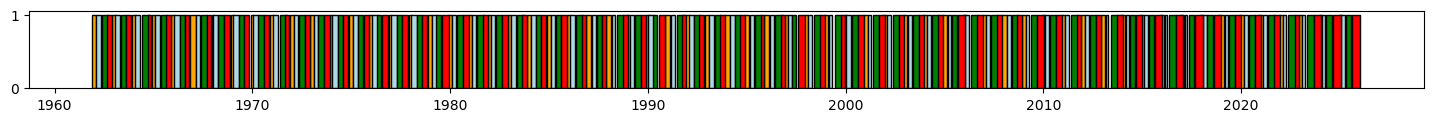

In [56]:
WLn = WL/sums
SpLn = SpL/sums
SLn = SL/sums

# bar positions
r = np.arange(min(x), max(x)+1)
r2 = r + ALn
r3 = r2 + SpLn
r4 = r3 + SLn

plt.figure(figsize=(18,1))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html
plt.bar(
    r, height=1, width=ALn, color="orange", align='center', edgecolor='black', label='autumn'
)
plt.bar(
    r2, height=1, width=WLn, color="lightblue", align='center', edgecolor='black', label='winter'
)
plt.bar(
    r3, height=1, width=SpLn, color="green", align='center', edgecolor='black', label='spring'
)
plt.bar(
    r4, height=1, width=SLn, color="red", align='center', edgecolor='black', label='summer'
)

### One row for each season?

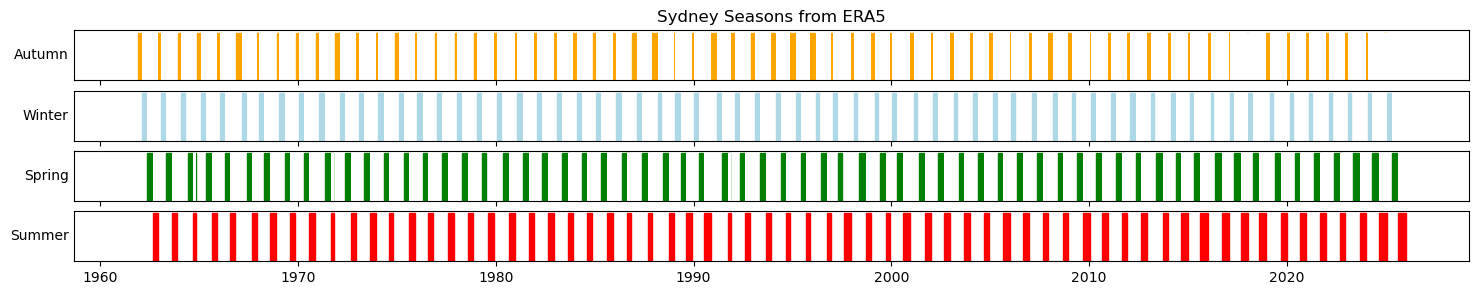

In [57]:
fig = plt.figure(figsize=(18,3))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html

# Autumn
ax1 = fig.add_subplot(4,1,1)
ax1.bar(r, height=1, width=ALn, color="orange", align='center', edgecolor='orange', label='autumn')
ax1.bar(r2, height=1, width=WLn, color="white", align='center', edgecolor='none', label='winter')
ax1.bar(r3, height=1, width=SpLn, color="white", align='center', edgecolor='none', label='spring')
ax1.bar(r4, height=1, width=SLn, color="white", align='center', edgecolor='none', label='summer')
ax1.set_ylabel("Autumn", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax1.set_yticks([])

# Winter
ax2 = fig.add_subplot(4,1,2, sharex = ax1)
ax2.bar(r, height=1, width=ALn, color="white", align='center', edgecolor='none', label='autumn')
ax2.bar(r2, height=1, width=WLn, color="lightblue", align='center', edgecolor='lightblue', label='winter')
ax2.bar(r3, height=1, width=SpLn, color="white", align='center', edgecolor='none', label='spring')
ax2.bar(r4, height=1, width=SLn, color="white", align='center', edgecolor='none', label='summer')
ax2.set_ylabel("Winter", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax2.set_yticks([])

# Spring
ax3 = fig.add_subplot(4,1,3, sharex = ax1)
ax3.bar(r, height=1, width=ALn, color="white", align='center', edgecolor='none', label='autumn')
ax3.bar(r2, height=1, width=WLn, color="white", align='center', edgecolor='none', label='winter')
ax3.bar(r3, height=1, width=SpLn, color="green", align='center', edgecolor='green', label='spring')
ax3.bar(r4, height=1, width=SLn, color="white", align='center', edgecolor='none', label='summer')
ax3.set_ylabel("Spring", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax3.set_yticks([])


# Summer
ax4 = fig.add_subplot(4,1,4, sharex=ax1)
ax4.bar(
    r, height=1, width=ALn, color="white", align='center', edgecolor='none', label='autumn'
)
ax4.bar(
    r2, height=1, width=WLn, color="white", align='center', edgecolor='none', label='winter'
)
ax4.bar(
    r3, height=1, width=SpLn, color="white", align='center', edgecolor='none', label='spring'
)
ax4.bar(
    r4, height=1, width=SLn, color="red", align='center', edgecolor='red', label='summer'
)
ax4.set_ylabel("Summer", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax4.set_yticks([])

ax1.set_title("Sydney Seasons from ERA5")
plt.show()


### Stacked bars for less horizontal space

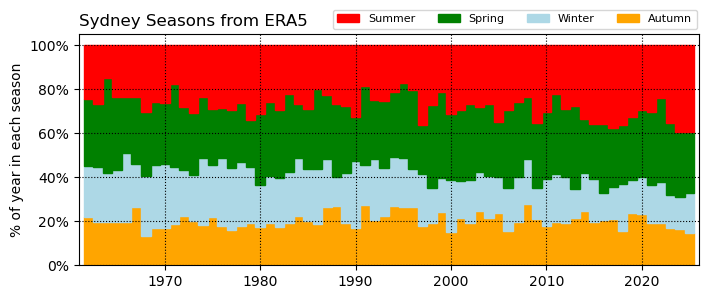

In [58]:
# pretty easy since the data is already defined above

fs=8
barWidth = 1

fig = plt.figure(figsize=(10,3))

ax = fig.add_subplot()

# Autumn bars
plt.bar(x, ALn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
# Winter, on top of the first ones
plt.bar(x, WLn, bottom=ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
# Spring
plt.bar(x, SpLn, bottom=ALn+WLn, color='green', edgecolor='green', width=barWidth, label="Spring")
# Summer
plt.bar(x, SLn, bottom=ALn+WLn+SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
 
# labels, etc
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.ylabel("% of year in each season")
# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
#get handles and labels https://www.statology.org/matplotlib-legend-order/
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [3,2,1,0]

#add legend to plot
# plt.legend()
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.4, 1), loc="lower left", ncol=4)#'upper left', bbox_to_anchor=(1, 1))

# add right labels
# ax2 = ax.twinx()
# ax2.set_ylim(1,0)
# ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1))

# adjust x axis so legend is visible
plt.xlim(1961,2026)
plt.grid(axis='both', which = 'both', linestyle=':', color="black")


plt.title("Sydney Seasons from ERA5", loc='left')

plt.show()

In [59]:
combined

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 65)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart   (time, lat, lon) float64 540MB 88.0 88.0 88.0 ... 219.0 219.0
    WinterEnd     (time, lat, lon) float64 540MB 125.0 125.0 ... 219.0 219.0
    WinterLength  (time, lat, lon) float64 540MB 38.0 38.0 38.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) float64 540MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerStart   (time, lat, lon) float64 540MB 135.0 135.0 ... 150.0 150.0
    SummerEnd     (time, lat, lon) float64 540MB 224.0 224.0 ... 252.0 252.0
    SummerLength  (time, lat, lon) float64 540MB 90.0 90.0 90.0 ... 103.0 103.0
    SpringLength  (time, lat, lon) float64 540MB 193.0 193.0 ... 137.0 137.0
    AutumnLength  (time, lat, lon) float64 540MB 0.0 0.0 0.0 ... 150.0 150.0

In [60]:
# read it back in and can re-use ds_seasons name
input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/1961-2025_ALL_season_stats.nc'
ds_seasons = xr.open_dataset(input_path)

In [61]:
ds_seasons

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    Coastal       (time, lat, lon) float64 540MB ...
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...
    SpringLength  (time, lat, lon) float64 540MB ...
    AutumnLength  (time, lat, lon) float64 540MB ...

### Load LSM because I should have kept it

In [62]:
file_path = '../../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

In [63]:
# merge together and drop coastal
ds_seasons = ds_seasons.merge(ds_lsm)
ds_seasons = ds_seasons.drop_vars(['Coastal'])
ds_seasons

<xarray.Dataset> Size: 4GB
Dimensions:       (lat: 721, lon: 1440, time: 65)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...
    SpringLength  (time, lat, lon) float64 540MB ...
    AutumnLength  (time, lat, lon) float64 540MB ...
    lsm           (lat, lon) float64 8MB ...

#### Write it out again this time with LSM and not Coastal

In [66]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/1961-2025_ALL_season_stats.nc'
ds_seasons.to_netcdf(output_path)

# **** Start Here Now

In [67]:
# read it back in and can re-use ds_seasons name
input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Seasons/1961-2025_ALL_season_stats.nc'
ds_seasons = xr.open_dataset(input_path)
ds_seasons

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (time, lat, lon) float64 540MB ...
    WinterEnd     (time, lat, lon) float64 540MB ...
    WinterLength  (time, lat, lon) float64 540MB ...
    SummerStart   (time, lat, lon) float64 540MB ...
    SummerEnd     (time, lat, lon) float64 540MB ...
    SummerLength  (time, lat, lon) float64 540MB ...
    SpringLength  (time, lat, lon) float64 540MB ...
    AutumnLength  (time, lat, lon) float64 540MB ...
    lsm           (lat, lon) float64 8MB ...

## Weighted mean for NH and SH, and also make func for any grid square

In [68]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_seasons.lat))
weights.name = "weights"

### Land Only for now

In [69]:
%%time

# takes 9 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes
nh_land_full = ds_seasons.where((ds_seasons.lsm > 0.5) & 
                             ((ds_seasons.lat >= nh_min) & (ds_seasons.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds_seasons.where((ds_seasons.lsm > 0.5) &  
                             ((ds_seasons.lat >= sh_max) & (ds_seasons.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# nh_ocean_full = ds.where((ds.lsm <= 0.5) & 
#                               ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])



CPU times: user 3.41 s, sys: 4.49 s, total: 7.91 s
Wall time: 8.77 s


In [70]:
nh_land_full

<xarray.Dataset> Size: 5kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart   (time) float64 520B 147.5 148.7 150.4 ... 164.5 167.5 162.4
    WinterEnd     (time) float64 520B 246.0 242.6 253.2 ... 231.9 233.6 233.6
    WinterLength  (time) float64 520B 99.52 94.8 103.8 ... 68.41 67.11 72.15
    SummerStart   (time) float64 520B 153.5 155.1 155.2 ... 146.5 143.0 142.3
    SummerEnd     (time) float64 520B 246.2 248.4 249.8 ... 260.2 260.1 258.6
    SummerLength  (time) float64 520B 93.63 94.28 95.67 ... 114.7 118.1 117.3
    SpringLength  (time) float64 520B 0.0 92.1 95.62 83.59 ... 94.0 94.08 91.71
    AutumnLength  (time) float64 520B 84.35 83.34 83.56 ... 87.29 90.34 86.77
    lsm           float64 8B 0.9671

In [71]:
# create data for bar plot
# get fraction of 365 days that are each season each year
x = ds_seasons.time.dt.year.values
nh_AL = nh_land_full.AutumnLength.values#/365.0
nh_WL = nh_land_full.WinterLength.values#/365.0
nh_SpL = nh_land_full.SpringLength.values#/365.0
nh_SL = nh_land_full.SummerLength.values#/365.0
nh_sums = nh_AL + nh_WL + nh_SpL + nh_SL
print(nh_sums)

# normalize so each year has same total length and each season is a fraction of that year
nh_ALn = nh_AL/nh_sums
nh_WLn = nh_WL/nh_sums
nh_SpLn = nh_SpL/nh_sums
nh_SLn = nh_SL/nh_sums


# same for SH
sh_AL = sh_land_full.AutumnLength.values#/365.0
sh_WL = sh_land_full.WinterLength.values#/365.0
sh_SpL = sh_land_full.SpringLength.values#/365.0
sh_SL = sh_land_full.SummerLength.values#/365.0
sh_sums = sh_AL + sh_WL + sh_SpL + sh_SL

# normalize so each year has same total length and each season is a fraction of that year
sh_ALn = sh_AL/sh_sums
sh_WLn = sh_WL/sh_sums
sh_SpLn = sh_SpL/sh_sums
sh_SLn = sh_SL/sh_sums

[277.49356278 364.52012582 378.63191291 365.14399346 363.04637294
 370.521381   364.83076808 373.0602576  366.52363619 371.25338326
 365.59056526 364.58108804 369.67870823 366.88761632 373.27625892
 357.2028705  372.10799118 370.76215262 368.51752719 358.69564031
 377.35449512 365.04425386 370.57916555 368.31359918 363.53773841
 367.11456552 371.70774672 362.29511324 364.98347815 374.88934803
 365.32953771 368.06244886 371.68783499 358.65390339 378.78734849
 363.86074859 367.27770006 366.88252254 365.9309334  369.57682139
 361.39328679 377.55785647 363.39014296 372.21804755 363.98070717
 366.84720837 369.27522016 368.4147098  364.20457343 376.05359047
 367.72307206 365.25239917 366.50527102 364.78141208 362.12164306
 370.82777425 373.2004145  366.91919409 358.202736   377.64228615
 366.43632936 367.11954549 364.36249525 369.63916478 367.89466818]


### NH Season Stripes

CPU times: user 82 ms, sys: 20.8 ms, total: 103 ms
Wall time: 165 ms


([], [])

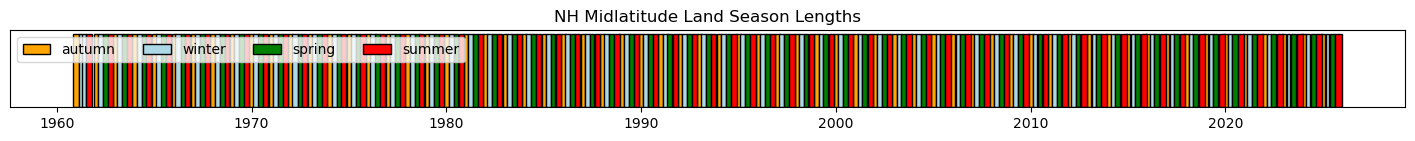

In [72]:
%%time

# bar positions
r = np.arange(min(x), max(x)+1)
r2 = r + nh_ALn
r3 = r2 + nh_SpLn
r4 = r3 + nh_SLn

plt.figure(figsize=(18,1))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html
plt.bar(
    r, height=1, width= nh_ALn, color="orange", align='center', edgecolor='black', label='autumn'
)
plt.bar(
    r2, height=1, width= nh_WLn, color="lightblue", align='center', edgecolor='black', label='winter'
)
plt.bar(
    r3, height=1, width= nh_SpLn, color="green", align='center', edgecolor='black', label='spring'
)
plt.bar(
    r4, height=1, width= nh_SLn, color="red", align='center', edgecolor='black', label='summer'
)
plt.title("NH Midlatitude Land Season Lengths")
plt.legend(loc='upper left', ncol=4)
plt.yticks([])

CPU times: user 71.4 ms, sys: 5.05 ms, total: 76.4 ms
Wall time: 75.8 ms


(1990.0, 2025.0)

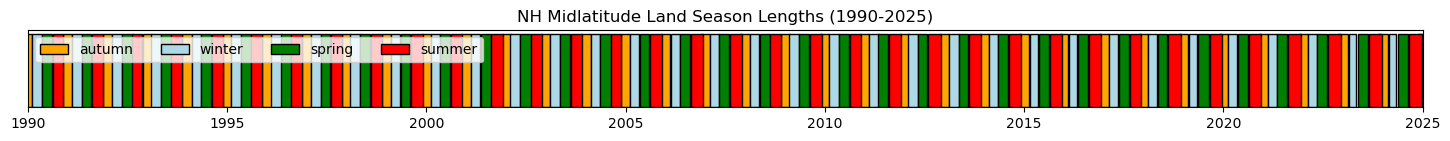

In [73]:
%%time

# bar positions
r = np.arange(min(x), max(x)+1)
r2 = r + nh_ALn
r3 = r2 + nh_SpLn
r4 = r3 + nh_SLn

plt.figure(figsize=(18,1))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html
plt.bar(
    r, height=1, width= nh_ALn, color="orange", align='center', edgecolor='black', label='autumn'
)
plt.bar(
    r2, height=1, width= nh_WLn, color="lightblue", align='center', edgecolor='black', label='winter'
)
plt.bar(
    r3, height=1, width= nh_SpLn, color="green", align='center', edgecolor='black', label='spring'
)
plt.bar(
    r4, height=1, width= nh_SLn, color="red", align='center', edgecolor='black', label='summer'
)
plt.title("NH Midlatitude Land Season Lengths (1990-2025)")
plt.legend(loc='upper left', ncol=4)
plt.yticks([])
plt.xlim(1990,2025)

#### Swap green with something else (Nala suggested pink)

CPU times: user 65.7 ms, sys: 4.47 ms, total: 70.2 ms
Wall time: 69.1 ms


(1990.0, 2025.0)

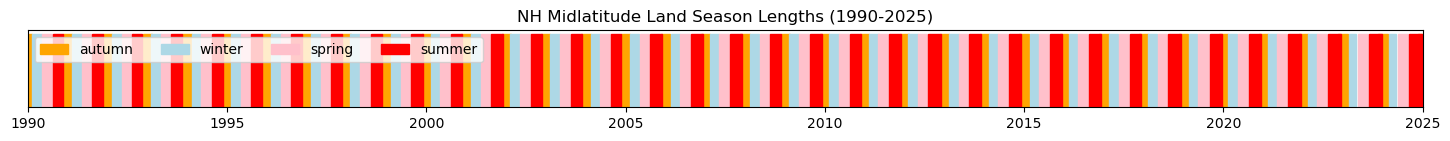

In [74]:
%%time

# bar positions
r = np.arange(min(x), max(x)+1)
r2 = r + nh_ALn
r3 = r2 + nh_SpLn
r4 = r3 + nh_SLn

plt.figure(figsize=(18,1))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html
# add alpha to allow saturation/transparency to indicate length
plt.bar(
    r, height=1, width= nh_ALn, color="orange", align='center', edgecolor='orange', label='autumn', alpha=1)
plt.bar(
    r2, height=1, width= nh_WLn, color="lightblue", align='center', edgecolor='lightblue', label='winter', alpha=1)
plt.bar(
    r3, height=1, width= nh_SpLn, color="pink", align='center', edgecolor='pink', label='spring', alpha=1)
plt.bar(
    r4, height=1, width= nh_SLn, color="red", align='center', edgecolor='red', label='summer', alpha=1)
plt.title("NH Midlatitude Land Season Lengths (1990-2025)")
plt.legend(loc='upper left', ncol=4)
plt.yticks([])
plt.xlim(1990,2025)

### Calculate lengths as anomalies from 1961-1990 average season lengths

In [75]:
nh_seas_mean_base = nh_land_full.sel(time=slice('1961','1990')).mean()
nh_seas_mean_base

<xarray.Dataset> Size: 72B
Dimensions:       ()
Data variables:
    WinterStart   float64 8B 150.0
    WinterEnd     float64 8B 246.3
    WinterLength  float64 8B 97.29
    SummerStart   float64 8B 153.8
    SummerEnd     float64 8B 247.0
    SummerLength  float64 8B 94.18
    SpringLength  float64 8B 87.48
    AutumnLength  float64 8B 85.99
    lsm           float64 8B 0.9671

In [76]:
nh_land_anom = nh_land_full - nh_seas_mean_base
nh_land_anom = nh_land_anom.drop_vars(['WinterStart','WinterEnd','SummerStart','SummerEnd','lsm'])
nh_land_anom

<xarray.Dataset> Size: 3kB
Dimensions:       (time: 65)
Coordinates:
  * time          (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterLength  (time) float64 520B 2.224 -2.489 6.482 ... -30.18 -25.14
    SummerLength  (time) float64 520B -0.5504 0.1046 1.497 ... 20.49 23.93 23.1
    SpringLength  (time) float64 520B -87.48 4.62 8.145 ... 6.52 6.604 4.231
    AutumnLength  (time) float64 520B -1.642 -2.654 -2.43 ... 1.292 4.349 0.7741

#### 5 yr averages

In [77]:
nh_land_anom_5Y = nh_land_anom.resample(time='5YE').mean(dim='time')
nh_land_anom_5Y

<xarray.Dataset> Size: 560B
Dimensions:       (time: 14)
Coordinates:
  * time          (time) datetime64[ns] 112B 1961-12-31 ... 2026-12-31
Data variables:
    WinterLength  (time) float64 112B 2.224 3.005 2.267 ... -16.0 -19.42 -25.56
    SummerLength  (time) float64 112B -0.5504 -1.515 -1.816 ... 16.2 17.21 21.92
    SpringLength  (time) float64 112B -87.48 2.701 2.327 ... 2.571 5.749 5.029
    AutumnLength  (time) float64 112B -1.642 -0.7564 0.5353 ... -0.002025 0.9301

Text(0, 0.5, 'Length vs 1961-1990 Mean [Days]')

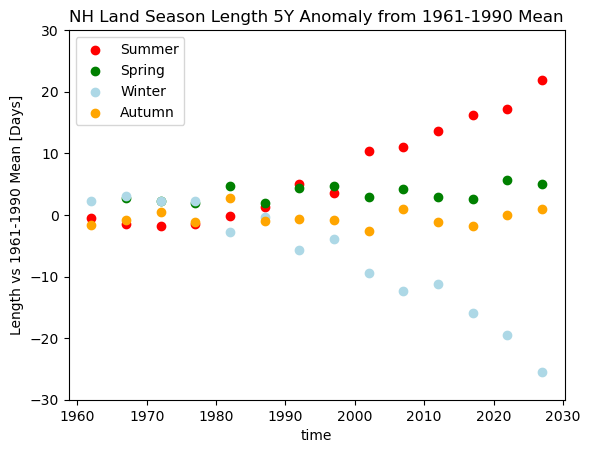

In [78]:
# sel(time=slice('1990','2025')).
nh_land_anom_5Y.SummerLength.plot.scatter(label="Summer", color="red")
nh_land_anom_5Y.SpringLength.plot.scatter(label="Spring", color="green")
nh_land_anom_5Y.WinterLength.plot.scatter(label="Winter", color="lightblue")
nh_land_anom_5Y.AutumnLength.plot.scatter(label="Autumn", color="orange")
plt.legend()
plt.ylim(-30,30)
plt.title("NH Land Season Length 5Y Anomaly from 1961-1990 Mean")
plt.ylabel("Length vs 1961-1990 Mean [Days]")
#plt.xlim(dt(1989,1,1),dt(2025,12,31))


In [308]:
dt(1990,1,1)

datetime.datetime(1990, 1, 1, 0, 0)

### One row for each season

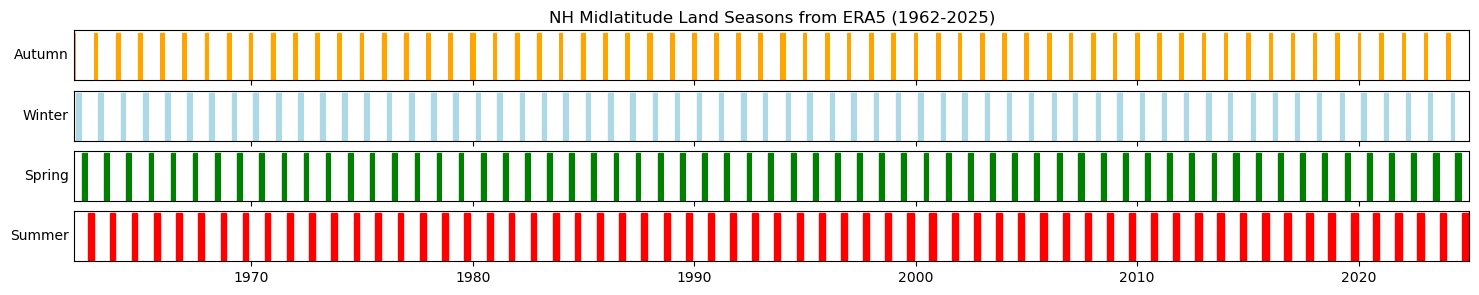

In [79]:
fig = plt.figure(figsize=(18,3))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html

# Autumn
ax1 = fig.add_subplot(4,1,1)
ax1.bar(r, height=1, width=nh_ALn, color="orange", align='center', edgecolor='orange', label='autumn')
ax1.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax1.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax1.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax1.set_ylabel("Autumn", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
plt.xlim(1962,2025)
ax1.set_yticks([])

# Winter
ax2 = fig.add_subplot(4,1,2, sharex = ax1)
ax2.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax2.bar(r2, height=1, width=nh_WLn, color="lightblue", align='center', edgecolor='lightblue', label='winter')
ax2.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax2.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax2.set_ylabel("Winter", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax2.set_yticks([])

# Spring
ax3 = fig.add_subplot(4,1,3, sharex = ax1)
ax3.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax3.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax3.bar(r3, height=1, width=nh_SpLn, color="green", align='center', edgecolor='green', label='spring')
ax3.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax3.set_ylabel("Spring", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax3.set_yticks([])


# Summer
ax4 = fig.add_subplot(4,1,4, sharex=ax1)
ax4.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax4.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax4.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax4.bar(r4, height=1, width=nh_SLn, color="red", align='center', edgecolor='red', label='summer')
ax4.set_ylabel("Summer", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax4.set_yticks([])

ax1.set_title("NH Midlatitude Land Seasons from ERA5 (1962-2025)")
plt.show()


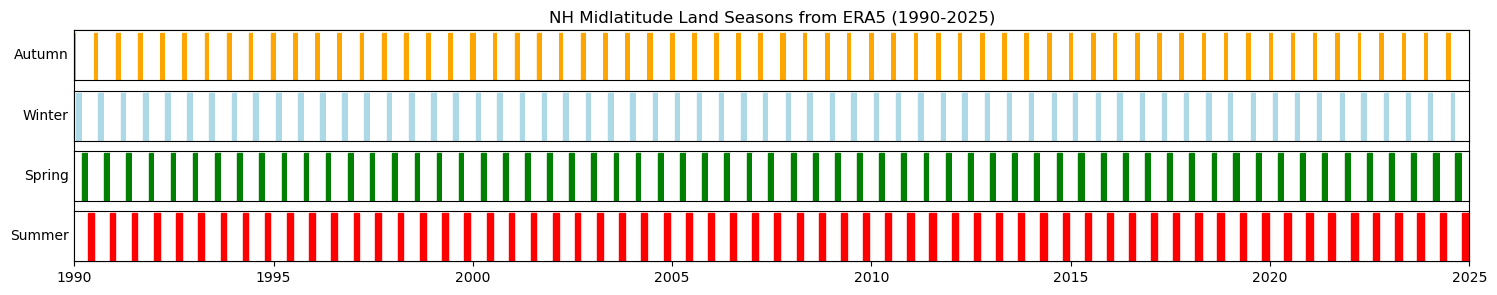

In [80]:
fig = plt.figure(figsize=(18,3))
# using ideas from https://era-explorer.climate.copernicus.eu/notebooks/content/temperature/warming_stripes.html

plt.xlim(1990,2025)
plt.yticks([])

# Autumn
ax1 = fig.add_subplot(4,1,1, sharex=ax4)
ax1.bar(r, height=1, width=nh_ALn, color="orange", align='center', edgecolor='orange', label='autumn')
ax1.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax1.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax1.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax1.set_ylabel("Autumn", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax1.set_yticks([])
ax1.set_xticks([])

# Winter
ax2 = fig.add_subplot(4,1,2, sharex = ax4)
ax2.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax2.bar(r2, height=1, width=nh_WLn, color="lightblue", align='center', edgecolor='lightblue', label='winter')
ax2.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax2.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax2.set_ylabel("Winter", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax2.set_yticks([])
ax2.set_xticks([])

# Spring
ax3 = fig.add_subplot(4,1,3, sharex = ax4)
ax3.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax3.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax3.bar(r3, height=1, width=nh_SpLn, color="green", align='center', edgecolor='green', label='spring')
ax3.bar(r4, height=1, width=nh_SLn, color="white", align='center', edgecolor='none', label='summer')
ax3.set_ylabel("Spring", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax3.set_yticks([])
ax3.set_xticks([])

# Summer
ax4 = fig.add_subplot(4,1,4, sharex=ax1)
ax4.bar(r, height=1, width=nh_ALn, color="white", align='center', edgecolor='none', label='autumn')
ax4.bar(r2, height=1, width=nh_WLn, color="white", align='center', edgecolor='none', label='winter')
ax4.bar(r3, height=1, width=nh_SpLn, color="white", align='center', edgecolor='none', label='spring')
ax4.bar(r4, height=1, width=nh_SLn, color="red", align='center', edgecolor='red', label='summer')
ax4.set_ylabel("Summer", rotation='horizontal', verticalalignment='center', horizontalalignment='right')
ax4.set_yticks([])

ax1.set_title("NH Midlatitude Land Seasons from ERA5 (1990-2025)")
plt.show()


### NH Land Stacked Bars

Update - order needs to be Spring - Summer - Autumn - Winter starting with 1962 (first year with full set, and winter starts in 1962 but spans into 1963)

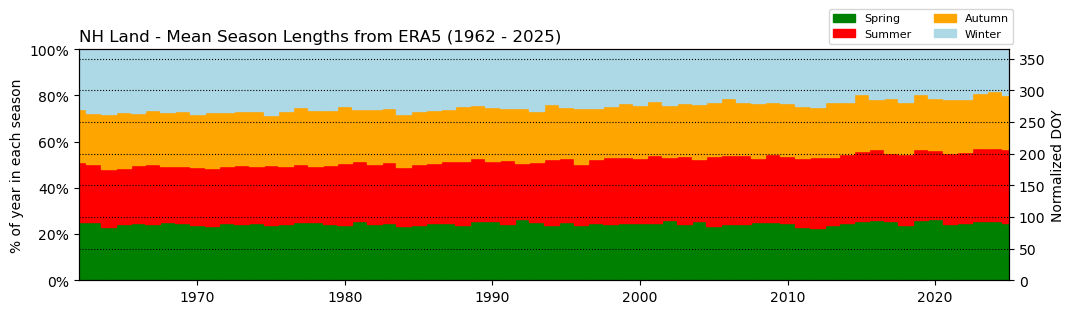

In [81]:
fs=8
barWidth = 1

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot()

# Spring
plt.bar(x, nh_SpLn, color='green', edgecolor='green', width=barWidth, label="Spring")
# Summer
plt.bar(x, nh_SLn, bottom = nh_SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
# Autumn bars
plt.bar(x, nh_ALn, bottom = nh_SpLn + nh_SLn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
# Winter, on top of the first ones - in NH spans two calendar years
plt.bar(x, nh_WLn, bottom = nh_SpLn + nh_SLn + nh_ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")


 
# labels, etc
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.ylabel("% of year in each season")

# Put a legend to the right of the current axis
#get handles and labels https://www.statology.org/matplotlib-legend-order/
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [0,1,2,3]

#add legend to plot
# plt.legend()
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))

ax.set_ylim(0,1)

# add right labels
ax2 = ax.twinx()

ax2.set_ylim(0,365)
ax2.set_ylabel("Normalized DOY")

# adjust x axis so legend is visible
plt.xlim(1962,2025)
plt.grid(axis='both', which = 'both', linestyle=':', color="black")


plt.title("NH Land - Mean Season Lengths from ERA5 (1962 - 2025)", loc='left')

plt.show()

### SH Land Stacked Bars

Update - order needs to be Autumn - Winter - Spring - Summer starting with 1962 (first year with full set, and summer starts in 1962 but spans into 1963)

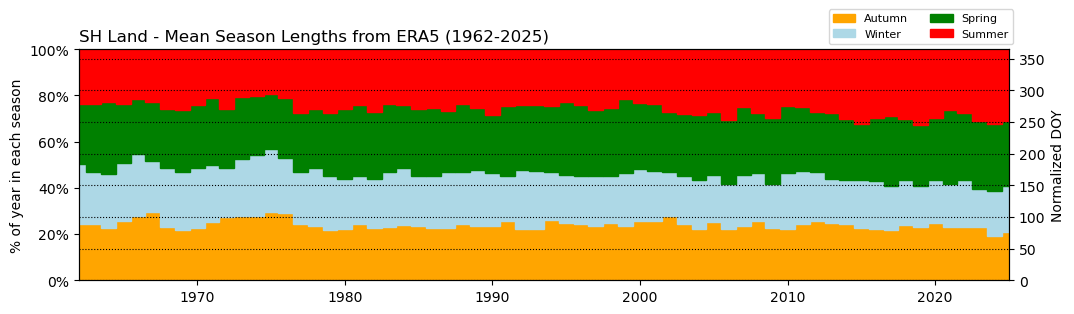

In [82]:
fs=8
barWidth = 1

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot()

# Autumn bars
plt.bar(x, sh_ALn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
# Winter, on top of the first ones
plt.bar(x, sh_WLn, bottom=sh_ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
# Spring
plt.bar(x, sh_SpLn, bottom= sh_ALn + sh_WLn, color='green', edgecolor='green', width=barWidth, label="Spring")
# Summer
plt.bar(x, sh_SLn, bottom= sh_ALn + sh_WLn + sh_SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
 
# labels, etc
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.ylabel("% of year in each season")

# Put a legend to the right of the current axis
#get handles and labels https://www.statology.org/matplotlib-legend-order/
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [0,1,2,3]

#add legend to plot
# plt.legend()
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))

ax.set_ylim(0,1)

# add right labels
ax2 = ax.twinx()

ax2.set_ylim(0,365)
ax2.set_ylabel("Normalized DOY")

# adjust x axis so legend is visible
plt.xlim(1962,2025)
plt.grid(axis='both', which = 'both', linestyle=':', color="black")


plt.title("SH Land - Mean Season Lengths from ERA5 (1962-2025)", loc='left')

plt.show()

### Function for any lat/lon

In [83]:
def MakeSeasonsPlot(input_lat, input_lon):
    '''

    Function that produces the length of each season over 1961-2025 (ds_seasons is already loaded) as a stacked bar plot.
    In in SH, starts with Autumn in 1962 (summer spans two calendar years), and in NH starts with Spring in 1962 (winter spans two years).

    Args:
        input_lat, input_lon: the lat and lon of the cell of interest, note func uses method='nearest'
        to get the nearest grid square from ERA5 at 0.25 deg resolution. Lat [-90,90], Lon [-180, 180]
        
    Returns:
        nothing
        
    Example:
        # for Vancouver, BC
        MakeSeasonsPlot(49.246, -123.116)

    '''

    if ((input_lat > -23.5) & (input_lat < 23.5)):
        print("Grid location not in midlatitudes! Results may be unexpected!")

    # filter data to nearest location of interested 
    ds = ds_seasons.sel(lat=input_lat, lon=input_lon, method='nearest')
    ds = ds.sel(time=slice('1962','2025'))

    # remove years with no winter for plot
    #ds = ds.where(ds.WinterLength > 0)
    
    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds.time.dt.year.values
    # AL = ds.AutumnLength.values/365.0
    # WL = ds.WinterLength.values/365.0
    # SpL = ds.SpringLength.values/365.0
    # SL = ds.SummerLength.values/365.0

    AL = np.abs(ds.AutumnLength/365.0)
    WL = np.abs(ds.WinterLength/365.0)
    SpL = np.abs(ds.SpringLength/365.0)
    SL = np.abs(ds.SummerLength/365.0)
    sums = AL + WL + SpL + SL
    
    # what if WL == 0?
    sums = xr.where((ds["WinterLength"] == 0), AL + SpL + SL, AL + WL + SpL + SL)
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn = AL/sums
    WLn = WL/sums
    SpLn = SpL/sums
    SLn = SL/sums

    # plotting
    fs=8
    barWidth = 1
    
    fig = plt.figure(figsize=(12,3))
    ax = fig.add_subplot()

    if (input_lat <= -23.5):
        # Autumn bars
        plt.bar(x, ALn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn, bottom=ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn, bottom= ALn + WLn, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn, bottom= ALn + WLn + SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # Spring
        plt.bar(x, SpLn, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn, bottom = SpLn, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn, bottom = SpLn + SLn, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn, bottom = SpLn + SLn + ALn, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.ylabel("% of year in each season")
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    # Put a legend to the right of the current axis
    handles, labels = plt.gca().get_legend_handles_labels()
        
    #specify order of items in legend
    order = [0,1,2,3]
    
    #add legend to plot
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(0.8, 1), loc="lower left", ncol=2)#'upper left', bbox_to_anchor=(1, 1))
    
    ax.set_ylim(0,1)
    
    # add right labels
    ax2 = ax.twinx()
    
    ax2.set_ylim(0,365)
    ax2.set_ylabel("Normalized DOY")   
    # limit x to complete data regardless of hemisphere
    plt.xlim(1962,2025)
    plt.grid(axis='both', which = 'both', linestyle=':', color="black")
    
    plt.title("Seasons from ERA5 for nearest cell to ["+str(input_lat)+", "+str(input_lon)+"]", loc='left')
    plt.show()

#### Vancouver

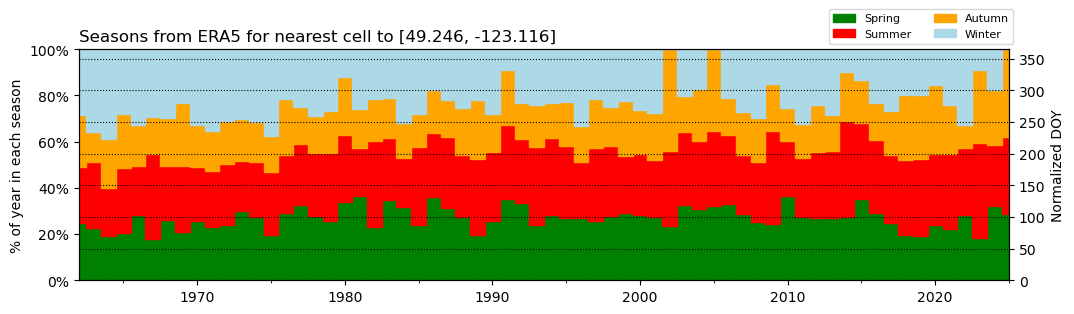

In [84]:
MakeSeasonsPlot(49.246, -123.116)

#### Vancouver 2002, 2005, 2025 Fourier fit yields WL = 0

In [85]:
ds_seasons.WinterLength.sel(lat=49.246, lon=-123.116, time='2002', method='nearest').values

array(0.)

#### Minneapolis

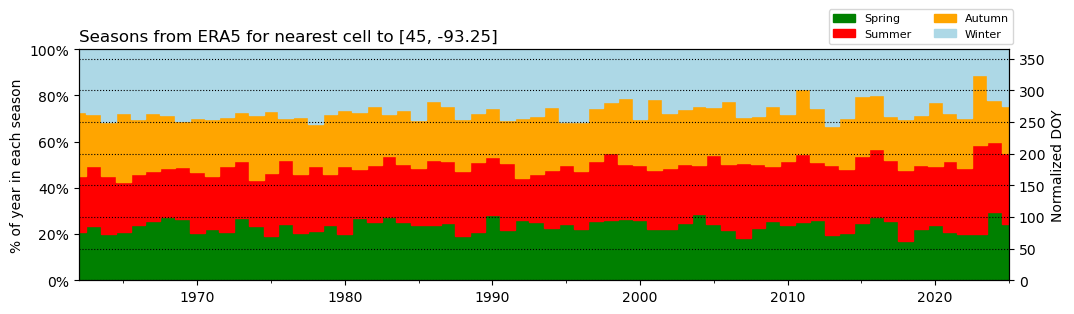

In [86]:
# Minneapolis
MakeSeasonsPlot(45, -93.25)

#### Montreal

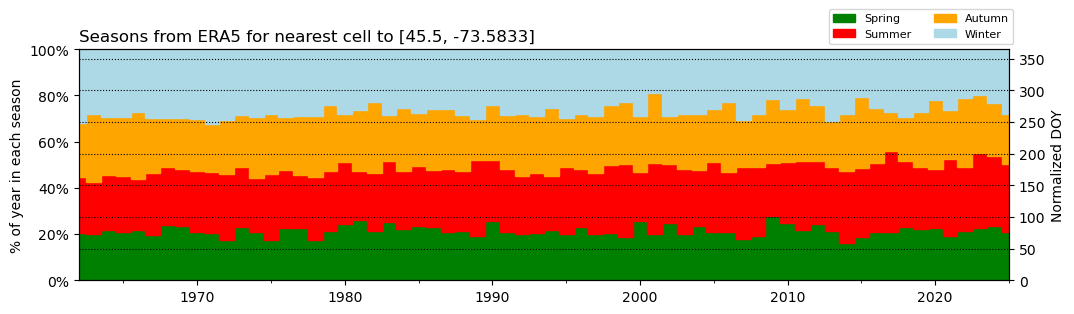

In [87]:
# Montreal 45.5	-73.5833
MakeSeasonsPlot(45.5, -73.5833)

#### Toronto

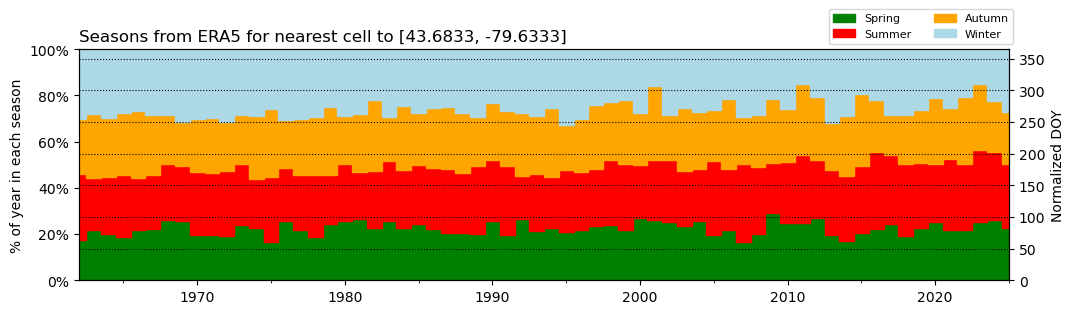

In [88]:
# Toronto 43.6833	-79.6333
MakeSeasonsPlot(43.6833,-79.6333)

#### Paris

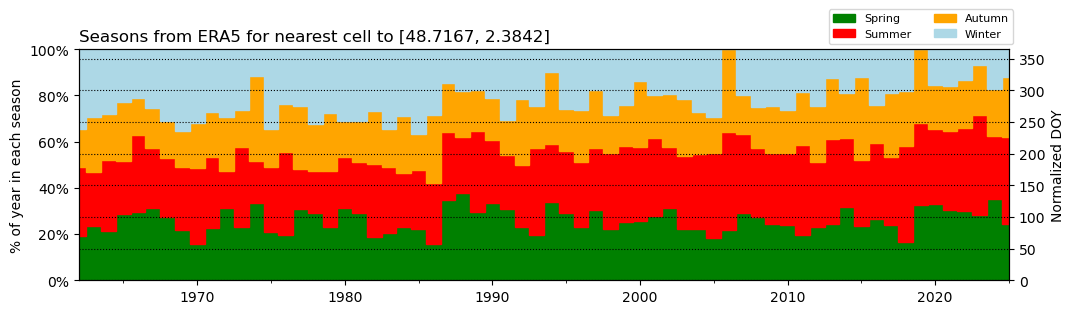

In [89]:
# Paris 48.7167	2.3842	
MakeSeasonsPlot(48.7167, 2.3842)

#### Sydney again

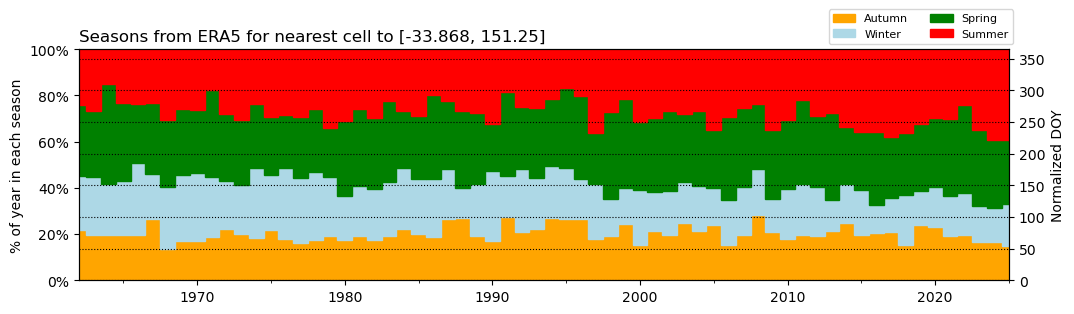

In [90]:
syd_lat = np.round(-33 - 52/60 - 4/3600, 3)
syd_lon = 151.25
MakeSeasonsPlot(syd_lat, syd_lon)

Grid location not in midlatitudes! Results may be unexpected!


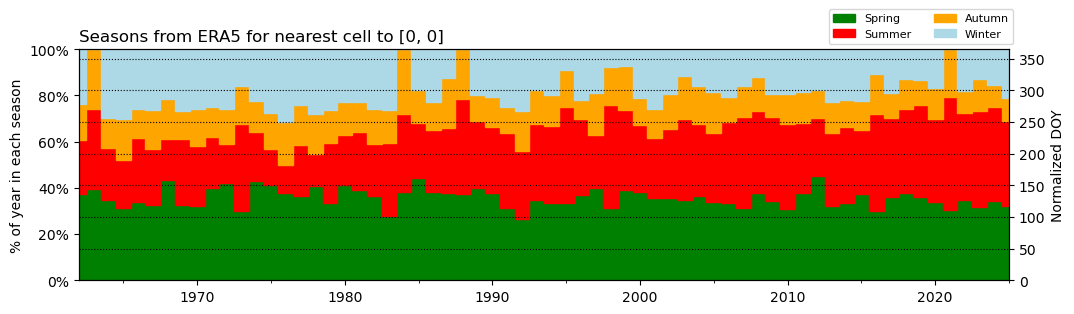

In [91]:
MakeSeasonsPlot(0,0)

#### Madrid

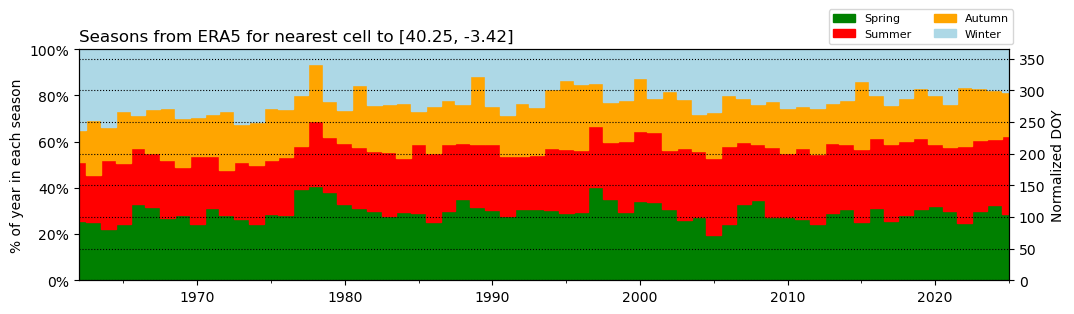

In [92]:
# Madrid 40.25, -3.42
MakeSeasonsPlot(40.25, -3.42)

### Zonal Season Length Plots

In [93]:
def MakeZonalSeasonsPlot(min_lat, max_lat, start_yr):
    '''

    Function that produces the mean length of each season over 1961-2025 (ds_seasons is already loaded) as a stacked bar plot.
    In in SH, starts with Autumn in 1962 (summer spans two calendar years), and in NH starts with Spring in 1962 (winter spans two years).
    The mean seasons are latitude weighted to those within the span of latitudes from min_lat to max_lat across all longitudes.

    The plots are produced and presented for land and ocean separately.

    Args:
        min_lat, max_lat: the lat range of interest
        start_yr: the earliest year to use (1962 is minimum), end is always 2025
        
    Returns:
        nothing
        
    Example:
        MakeZonalSeasonsPlot(20, 40, 1990)

    '''

    # filter data to complete years only
    ds = ds_seasons.sel(time=slice(str(start_yr),'2025'))
    
    # determine zonal means as weighted averages across all longitudes
    # land
    zone_land_full = ds.sel(lat=slice(min_lat, max_lat)).where((ds.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])
    # ocean
    zone_ocean_full = ds.sel(lat=slice(min_lat, max_lat)).where((ds.lsm <= 0.5)).weighted(weights).mean(dim=['lat','lon'])

    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds.time.dt.year.values

    ### Land
    AL_land = np.abs(zone_land_full.AutumnLength/365.0)
    WL_land = np.abs(zone_land_full.WinterLength/365.0)
    SpL_land = np.abs(zone_land_full.SpringLength/365.0)
    SL_land = np.abs(zone_land_full.SummerLength/365.0)
    sums_land = AL_land + WL_land + SpL_land + SL_land
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn_land = AL_land/sums_land
    WLn_land = WL_land/sums_land
    SpLn_land = SpL_land/sums_land
    SLn_land = SL_land/sums_land

    ### Ocean
    AL_ocean = np.abs(zone_ocean_full.AutumnLength/365.0)
    WL_ocean = np.abs(zone_ocean_full.WinterLength/365.0)
    SpL_ocean = np.abs(zone_ocean_full.SpringLength/365.0)
    SL_ocean = np.abs(zone_ocean_full.SummerLength/365.0)
    sums_ocean = AL_ocean + WL_ocean + SpL_ocean + SL_ocean
    
    # normalize so each year has same total length and each season is a fraction of that year
    ALn_ocean = AL_ocean/sums_ocean
    WLn_ocean = WL_ocean/sums_ocean
    SpLn_ocean = SpL_ocean/sums_ocean
    SLn_ocean = SL_ocean/sums_ocean
    
    # plotting
    fs=8
    barWidth = 1
    
    fig = plt.figure(figsize=(15,3), layout='constrained')
    ax = fig.add_subplot(1,2,1)

    ### LAND
    
    if (max_lat <= 0):
        # SH ordering
        # Autumn bars
        plt.bar(x, ALn_land, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn_land, bottom=ALn_land, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn_land, bottom= ALn_land + WLn_land, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_land, bottom= ALn_land + WLn_land + SpLn_land, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # NH ordering
        # Spring
        plt.bar(x, SpLn_land, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_land, bottom = SpLn_land, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn_land, bottom = SpLn_land + SLn_land, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn_land, bottom = SpLn_land + SLn_land + ALn_land, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.ylabel("% of year in each season")
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.set_ylim(0,1)
    
    # add right labels
    ax1 = ax.twinx()
    ax1.set_ylim(0,365)
    ax1.set_ylabel("Normalized DOY")
    ax1.set_yticks(np.arange(0,365,50))
    
    # limit x to complete data regardless of hemisphere
    ax.set_xlim(start_yr,2025)
    ax.grid(axis='both', which = 'both', linestyle=':', color="black")
    ax.set_title("Land")

    ### OCEAN
    ax2 = fig.add_subplot(1,2,2, sharey=ax)
    if (max_lat <= 0):
        # SH ordering
        # Autumn bars
        plt.bar(x, ALn_ocean, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones
        plt.bar(x, WLn_ocean, bottom=ALn_ocean, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")
        # Spring
        plt.bar(x, SpLn_ocean, bottom= ALn_ocean + WLn_ocean, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_ocean, bottom= ALn_ocean + WLn_ocean + SpLn_ocean, color='red', edgecolor='red', width=barWidth, label="Summer")

    else:
        # NH ordering
        # Spring
        plt.bar(x, SpLn_ocean, color='green', edgecolor='green', width=barWidth, label="Spring")
        # Summer
        plt.bar(x, SLn_ocean, bottom = SpLn_ocean, color='red', edgecolor='red', width=barWidth, label="Summer")
        # Autumn bars
        plt.bar(x, ALn_ocean, bottom = SpLn_ocean + SLn_ocean, color='orange', edgecolor='orange', width=barWidth, label="Autumn")
        # Winter, on top of the first ones - in NH spans two calendar years
        plt.bar(x, WLn_ocean, bottom = SpLn_ocean + SLn_ocean + ALn_ocean, color='lightblue', edgecolor='lightblue', width=barWidth, label="Winter")

    # labels, etc
    #plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
    #plt.ylabel("% of year in each season")
    ax2.xaxis.set_minor_locator(MultipleLocator(5))
    
    # Put a legend to the right of the current axis
    handles, labels = plt.gca().get_legend_handles_labels()
        
    #specify order of items in legend
    order = [0,1,2,3]
    
    #add legend to plot
    ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=fs, bbox_to_anchor=(-0.4, 0), loc="lower left", ncol=1)

    ax2.set_ylim(0,1)
    
    # add right labels
    ax3 = ax2.twinx()
    ax3.set_ylim(0,365)
    ax3.set_ylabel("Normalized DOY")
    ax3.set_yticks(np.arange(0,365,50))
    
    # limit x to complete data regardless of hemisphere
    plt.xlim(start_yr,2025)
    ax2.grid(axis='both', which = 'both', linestyle=':', color="black")
    ax2.set_title("Ocean")
    
    
    plt.suptitle(str(start_yr)+"-2025:"+" Seasons from ERA5 between ["+str(min_lat)+", "+str(max_lat)+"] Latitude\n")
    plt.show()

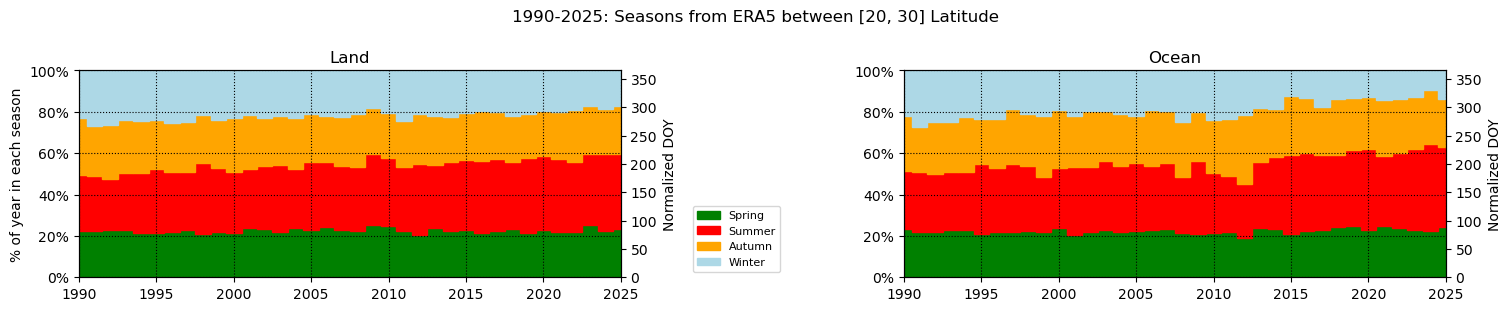

In [94]:
MakeZonalSeasonsPlot(20,30, 1990)

### NH Zonal by 10 deg

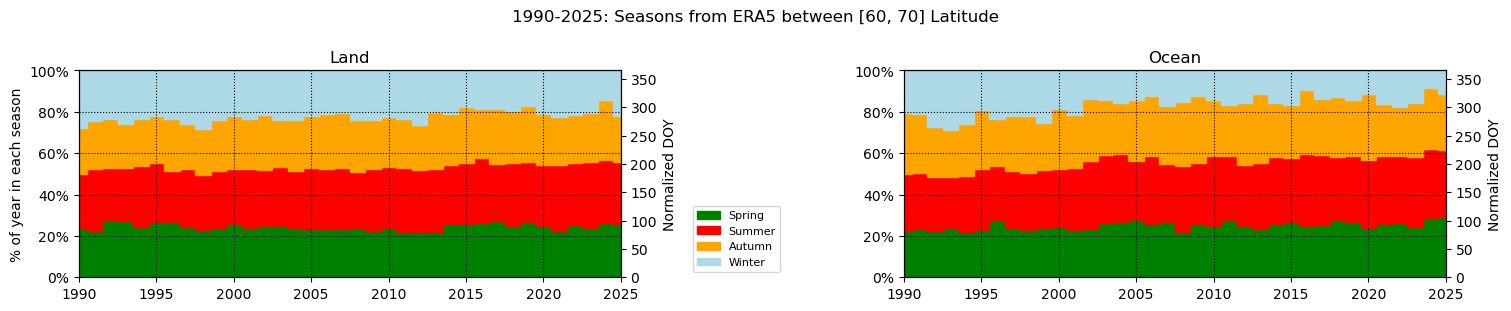

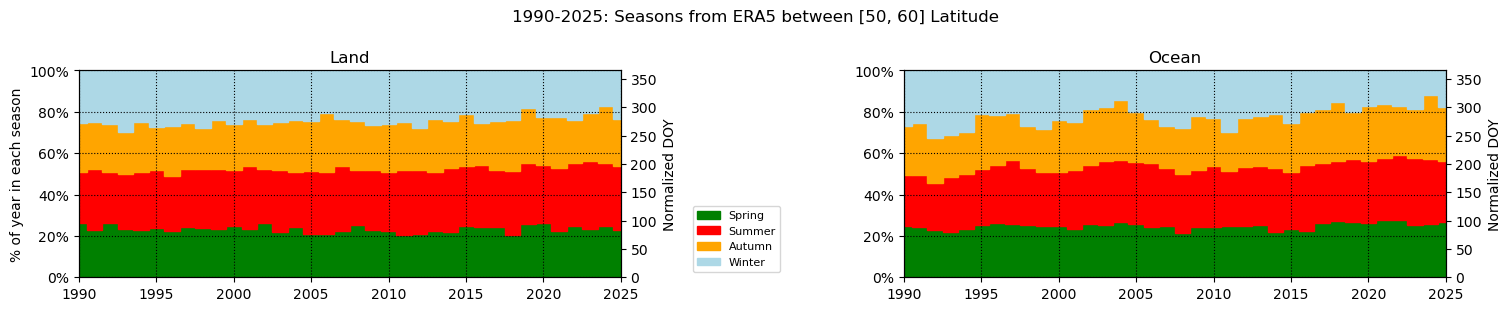

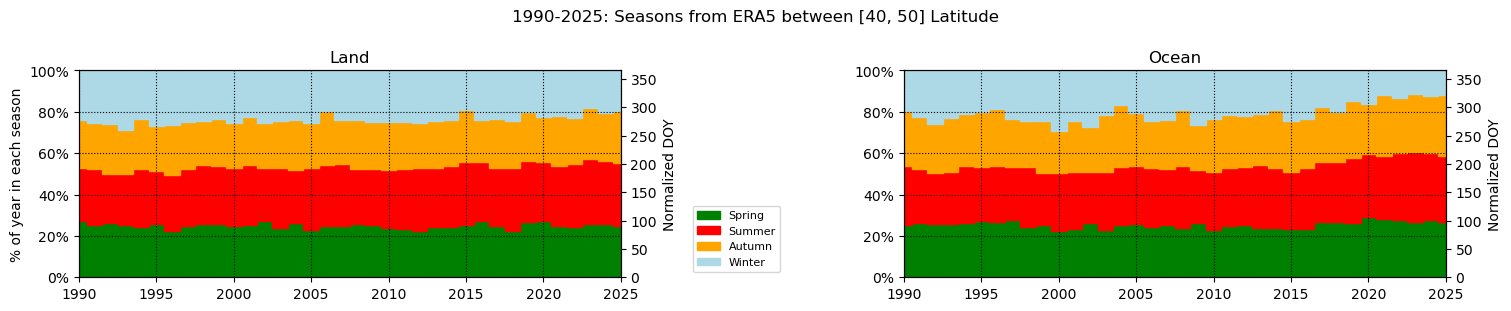

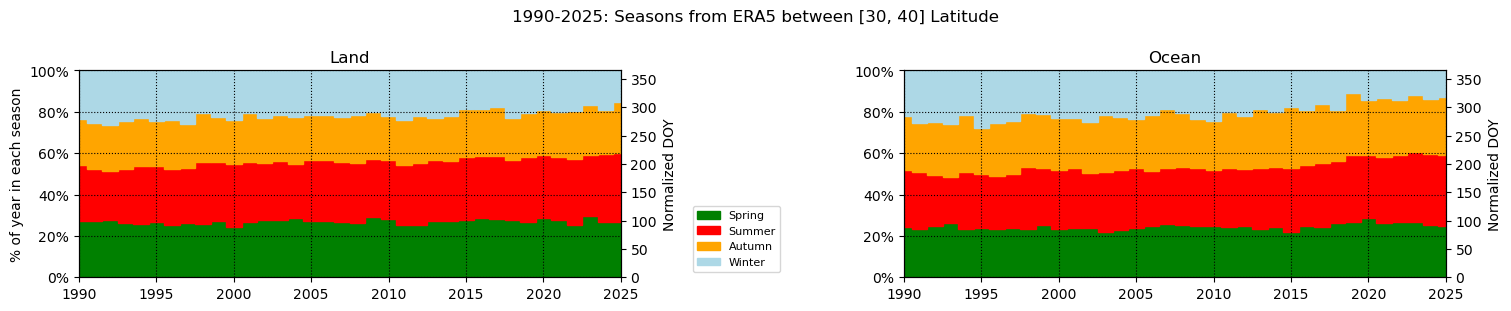

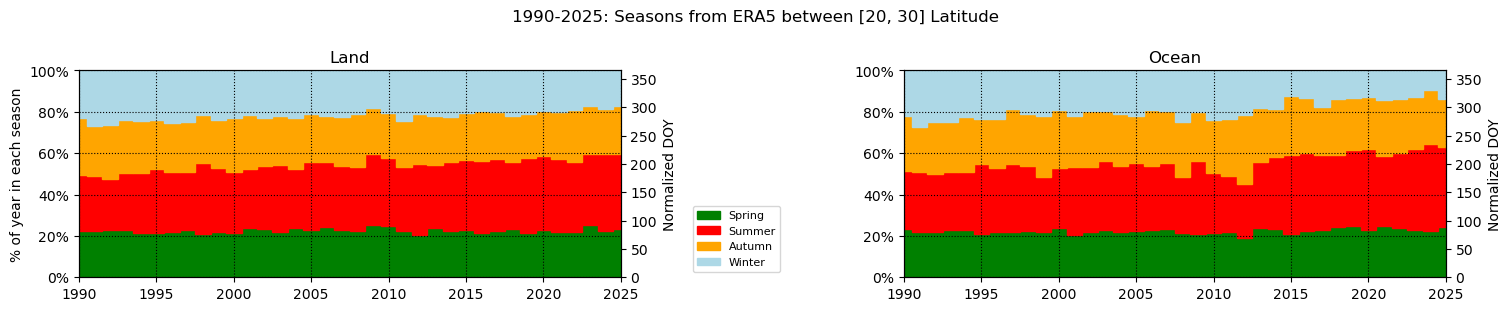

In [95]:
for i in np.arange(70,20,-10):
    MakeZonalSeasonsPlot(i-10, i, 1990)

### SH Zonal by 10 deg

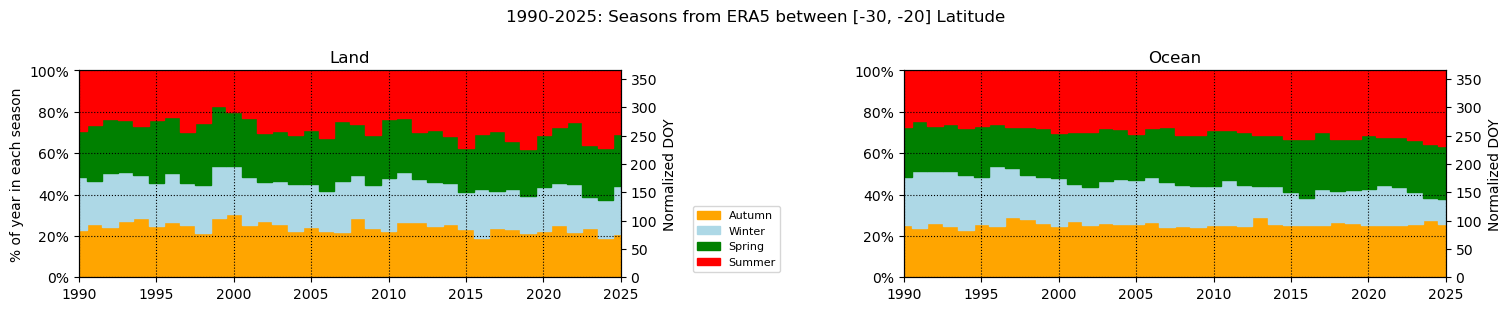

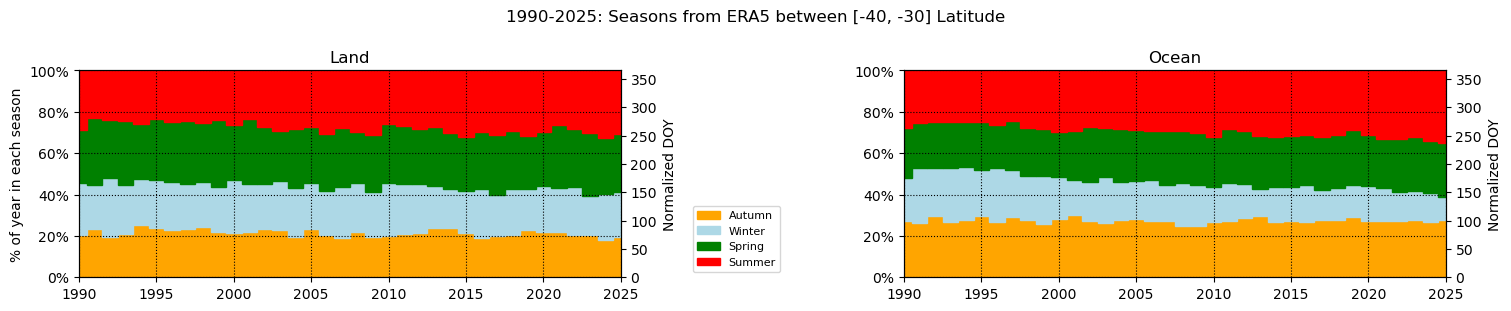

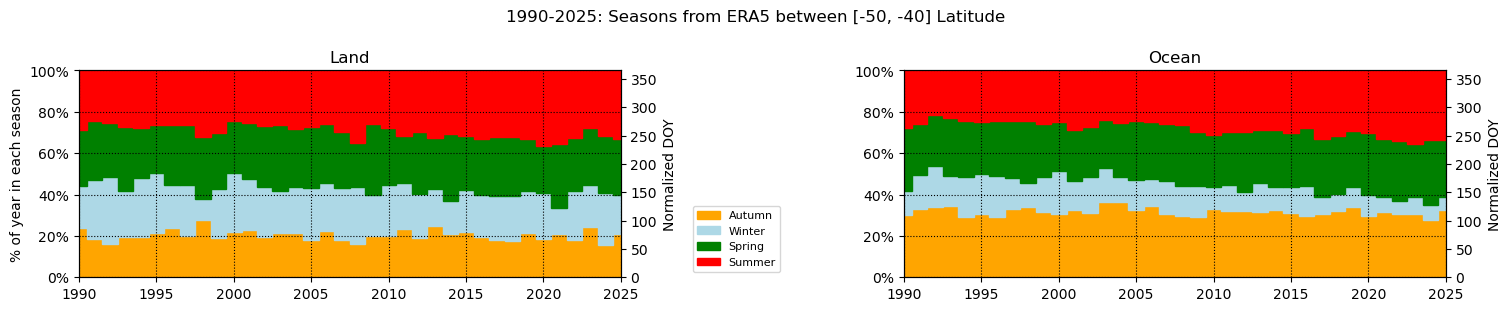

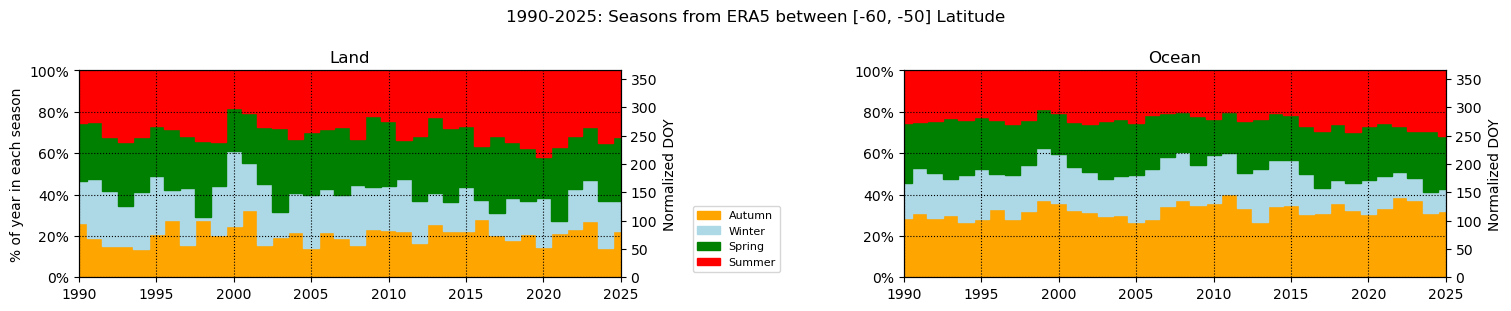

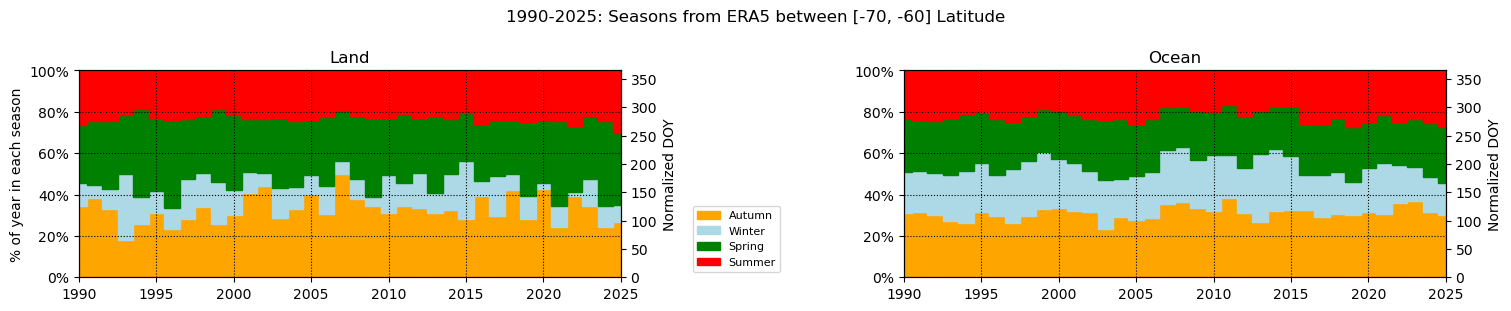

In [96]:
for i in np.arange(-20,-70,-10):
    MakeZonalSeasonsPlot(i-10, i, 1990)

## Circular Barplots of Seasons
- help from https://python-graph-gallery.com/circular-barplot-with-groups/

#### Create data frame for plot

In [97]:
# Toronto 43.6833	-79.6333
# test_lat = 43.6833
# test_lon = -79.6333

# Sydney
test_lat = np.round(-33 - 52/60 - 4/3600, 3)
test_lon = 151.25

# filter data to nearest location of interested 
ds_test = ds_seasons.sel(lat=test_lat, lon=test_lon, method='nearest')
ds_test = ds_test.sel(time=slice('1962','2025'))

# create data for bar plot
# get fraction of 365 days that are each season each year
x = ds_test.time.dt.year.values

AL = np.abs(ds_test.AutumnLength/365.0)
WL = np.abs(ds_test.WinterLength/365.0)
SpL = np.abs(ds_test.SpringLength/365.0)
SL = np.abs(ds_test.SummerLength/365.0)
sums = AL + WL + SpL + SL

# normalize so each year has same total length and each season is a fraction of that year
ALn = AL/sums
WLn = WL/sums
SpLn = SpL/sums
SLn = SL/sums

# Build a dataset
df = pd.DataFrame({
    "year": np.concatenate((x,x,x,x)),
    "value": np.concatenate((ALn, WLn, SpLn, SLn)),
    "group": ["Autumn"] * x.size + ["Winter"] * x.size + ["Spring"] * x.size + ["Summer"] * x.size
})

# Show 3 first rows
df

,year,value,group
0,1962,0.219577,Autumn
1,1963,0.196721,Autumn
2,1964,0.195055,Autumn
3,1965,0.197832,Autumn
4,1966,0.196023,Autumn
...,...,...,...
251,2021,0.301587,Summer
252,2022,0.240437,Summer
253,2023,0.351351,Summer
254,2024,0.394805,Summer


In [98]:
# created reduced set since 1990 because that will be too many bars
# and multiply the values by 100 to get percent of normalized year
df_an = df.query("year >= 1990")
df_an['value'] = df_an['value']*100
df_an

,year,value,group
28,1990,16.949153,Autumn
29,1991,27.322404,Autumn
30,1992,20.708447,Autumn
31,1993,22.191011,Autumn
32,1994,27.146814,Autumn
...,...,...,...
251,2021,30.158730,Summer
252,2022,24.043716,Summer
253,2023,35.135135,Summer
254,2024,39.480519,Summer


In [99]:
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax, skip=5):
    
    # This is the space between the end of the bar and the label
    padding = 3
    
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        # And finally add the text
        # only add every skip value, so skip=5 means every 5th year
        if ((label % skip) == 0):
            ax.text(
                x=angle, 
                y= value + padding, #(lambda value : value + padding if value > 0 else 0), 
                s=label, 
                ha=alignment, 
                va="center", 
                rotation=rotation, 
                rotation_mode="anchor"
            ) 


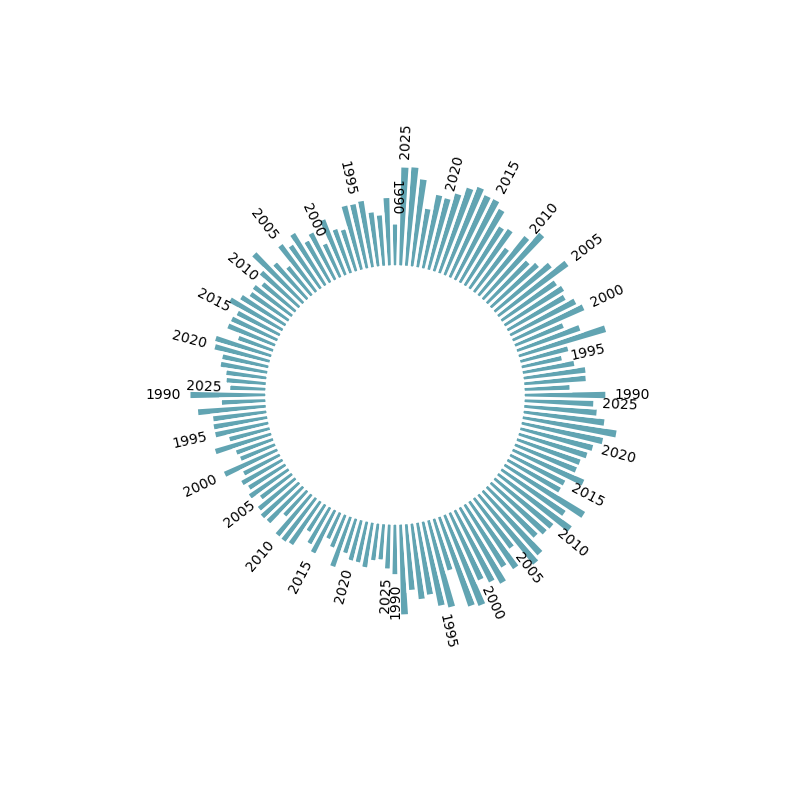

In [100]:
ANGLES = np.linspace(0, 2 * np.pi, len(df_an), endpoint=False)
VALUES = df_an["value"].values
LABELS = df_an["year"].values

# Determine the width of each bar. 
# The circumference is '2 * pi', so we divide that total width over the number of bars.
WIDTH = 2 * np.pi / len(VALUES)

# Determines where to place the first bar. 
# By default, matplotlib starts at 0 (the first bar is horizontal)
# but here we say we want to start at pi/2 (90 deg)
OFFSET = np.pi / 2

# Initialize Figure and Axis
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})

# Specify offset
ax.set_theta_offset(OFFSET)

# Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
ax.set_ylim(-50, 100)

# Remove all spines
ax.set_frame_on(False)

# Remove grid and tick marks
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

# Add bars
ax.bar(
    ANGLES, VALUES, width=WIDTH, linewidth=2,
    color="#61a4b2", edgecolor="white"
)

# Add labels
add_labels(ANGLES, VALUES, LABELS, OFFSET, ax, 5)

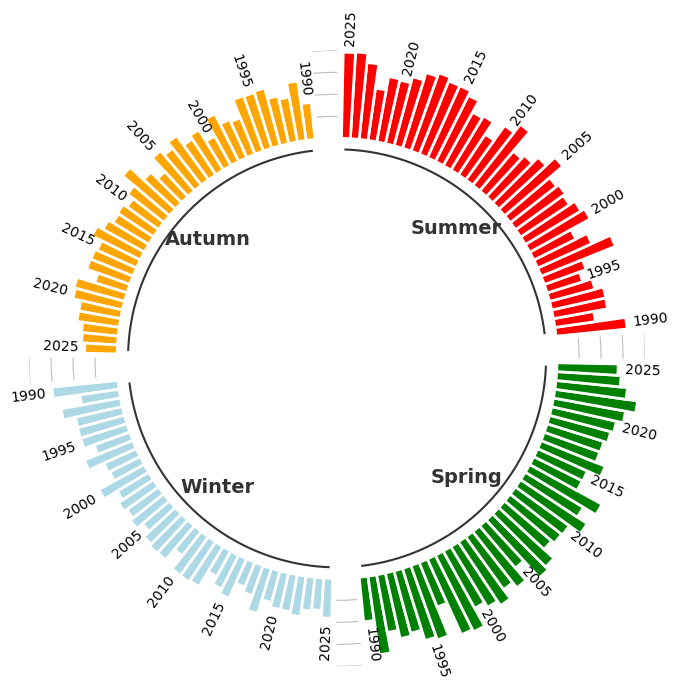

In [101]:
# All this part is like the code above
VALUES = df_an["value"].values
LABELS = df_an["year"].values
GROUP = df_an["group"].values

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in df_an.groupby("group")]

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-100, 40)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

GROUPS_SIZE = [len(i[1]) for i in df_an.groupby("group")]
COLORS = ["orange"]*36 + ["lightblue"]*36+ ["green"]*36 + ["red"]*36
#COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)

# Extra customization below here --------------------

# This iterates over the sizes of the groups adding reference
# lines and annotations.

offset = 0 
for group, size in zip(["Autumn", "Winter", "Spring", "Summer"], GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [-5] * 50, color="#333333")
    
    # Add text to indicate group
    ax.text(
        np.mean(x1), -20, group, color="#333333", fontsize=14, 
        fontweight="bold", ha="center", va="center"
    )
    
    # Add reference lines at 10, 20, 30, and 40 %
    x2 = np.linspace(ANGLES[offset], ANGLES[offset + PAD - 1], num=50)
    ax.plot(x2, [10] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [20] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [30] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [40] * 50, color="#bebebe", lw=0.8)
    
    offset += size + PAD

### OK, the circular plot works but doesn't show the trend as well as the stacked bars

In [102]:
seasons = np.unique(df_an.group.values)
seasons

array(['Autumn', 'Spring', 'Summer', 'Winter'], dtype=object)

In [103]:
for i,j in enumerate(seasons):
    print(i,j)

0 Autumn
1 Spring
2 Summer
3 Winter


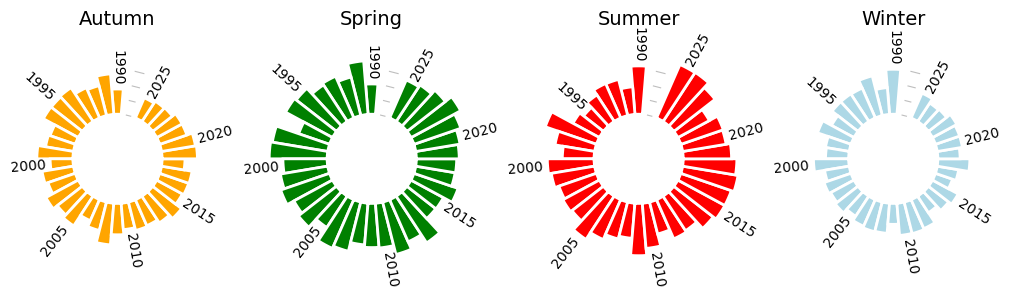

In [104]:
# one per season?

fig, axs = plt.subplots(1,4, figsize=(10,6), subplot_kw={"projection": "polar"}, layout='constrained')
axs = axs.flatten()

for i,j in enumerate(seasons):

    #ax = fig.add_subplot(2,2,i+1)
    df_tmp = df_an.query("group == @j")

    VALUES = df_tmp["value"].values
    LABELS = df_tmp["year"].values
    
    # 2 empty bars are added 
    PAD = 2
    ANGLES_N = len(VALUES) + PAD
    ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
    WIDTH = (2 * np.pi) / len(ANGLES)
    
    # The index contains non-empty bards
    IDXS = slice(0, ANGLES_N - PAD)
     
    #ANGLES = np.linspace(0, 2 * np.pi, len(df_tmp), endpoint=False)
    
    
    # Determine the width of each bar. 
    # The circumference is '2 * pi', so we divide that total width over the number of bars.
    #WIDTH = 2 * np.pi / len(VALUES)
    
    # Determines where to place the first bar. 
    # By default, matplotlib starts at 0 (the first bar is horizontal)
    # but here we say we want to start at pi/2 (90 deg)
    OFFSET = np.pi / 2
    
    # Specify offset
    axs[i].set_theta_offset(OFFSET)
    
    # Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
    axs[i].set_ylim(-30, 40)
    
    # Remove all spines
    axs[i].set_frame_on(False)
    
    # Remove grid and tick marks
    axs[i].xaxis.grid(False)
    axs[i].yaxis.grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

    COLORS = ["orange","green","red","lightblue"]
    
    # Add bars
    axs[i].bar(
        ANGLES[IDXS], VALUES, width=WIDTH, linewidth=2,
        color=COLORS[i], edgecolor="white"
    )
    
    # Add labels
    add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, axs[i])

    # Add reference lines at 0, 10, 20, and 30 %
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [0,0], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [10,10], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [20,20], color="#bebebe", lw=0.8)
    axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [30,30], color="#bebebe", lw=0.8)

    # title
    axs[i].set_title(j+"\n", fontsize=14)

### seems like it could be made better but the trends really don't come thru so moving on?
- maybe should make a function to do the four season circles for an input lat,lon and see

In [105]:
# function to create the seasonal circular bar plots for a given location

def CircularSeasonPlots(input_lat, input_lon):

    # build data frame
    ds_test = ds_seasons.sel(lat=input_lat, lon=input_lon, method='nearest')
    ds_test = ds_test.sel(time=slice('1990','2025'))
    
    # create data for bar plot
    # get fraction of 365 days that are each season each year
    x = ds_test.time.dt.year.values
    
    AL = np.abs(ds_test.AutumnLength/365.0)
    WL = np.abs(ds_test.WinterLength/365.0)
    SpL = np.abs(ds_test.SpringLength/365.0)
    SL = np.abs(ds_test.SummerLength/365.0)
    sums = AL + WL + SpL + SL
    
    # normalize so each year has same total length and each season is a fraction of that year
    # multiply by 100 to get Pct
    ALn = AL/sums * 100
    WLn = WL/sums * 100
    SpLn = SpL/sums * 100
    SLn = SL/sums * 100
    
    # Build a dataset
    df = pd.DataFrame({
        "year": np.concatenate((x,x,x,x)),
        "value": np.concatenate((ALn, WLn, SpLn, SLn)),
        "group": ["Autumn"] * x.size + ["Winter"] * x.size + ["Spring"] * x.size + ["Summer"] * x.size
    })
    #print(df)

    # make plots
    fig, axs = plt.subplots(1,4, figsize=(10,5), subplot_kw={"projection": "polar"}, layout='constrained')
    axs = axs.flatten()
    plt.suptitle("Seasons for ["+str(input_lat)+","+str(input_lon)+"] (1990-2025)", fontsize=18)

    # season order by hemisphere
    if (input_lat >=0):
        seasons = ["Spring","Summer","Autumn","Winter"]
        COLORS = ["green","red", "orange","lightblue"]
    else:
        seasons = ["Autumn","Winter","Spring","Summer"]
        COLORS = ["orange","lightblue", "green","red"]
        
    #seasons = np.unique(df.group.values)
    
    for i,j in enumerate(seasons):
    
        #ax = fig.add_subplot(2,2,i+1)
        df_tmp = df.query("group == @j")

        VALUES = df_tmp["value"].values
        LABELS = df_tmp["year"].values
        
        # 2 empty bars are added to create a gap for the visual
        PAD = 2
        ANGLES_N = len(df_tmp) + PAD
        ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
        # Determine the width of each bar. 
        # The circumference is '2 * pi', so we divide that total width over the number of bars including PAD.
        WIDTH = (2 * np.pi) / len(ANGLES)
        
        # The index contains non-empty bards
        IDXS = slice(0, ANGLES_N - PAD)
        
        #ANGLES = np.linspace(0, 2 * np.pi, len(df_tmp), endpoint=False)
        
        
        # Determines where to place the first bar. 
        # By default, matplotlib starts at 0 (the first bar is horizontal)
        # but here we say we want to start at pi/2 (90 deg)
        OFFSET = np.pi / 2
        
        # Specify offset
        axs[i].set_theta_offset(OFFSET)
        
        # Set limits for radial (y) axis. The negative lower bound creates the hole in the middle.
        axs[i].set_ylim(-30, 40)
        
        # Remove all spines
        axs[i].set_frame_on(False)
        
        # Remove grid and tick marks
        axs[i].xaxis.grid(False)
        axs[i].yaxis.grid(False)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        
        # Add bars
        axs[i].bar(
            ANGLES[IDXS], VALUES, width=WIDTH, linewidth=2,
            color=COLORS[i], edgecolor="white"
        )
        
        # Add labels
        add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, axs[i])

        # Add reference lines at 0, 10, 20, and 30 %
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [0,0], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [10,10], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [20,20], color="#bebebe", lw=0.8)
        axs[i].plot([2*np.pi-0.3,2*np.pi+0.4-0.6], [30,30], color="#bebebe", lw=0.8)
    
        axs[i].set_title(j+"\n\n", fontsize=14)

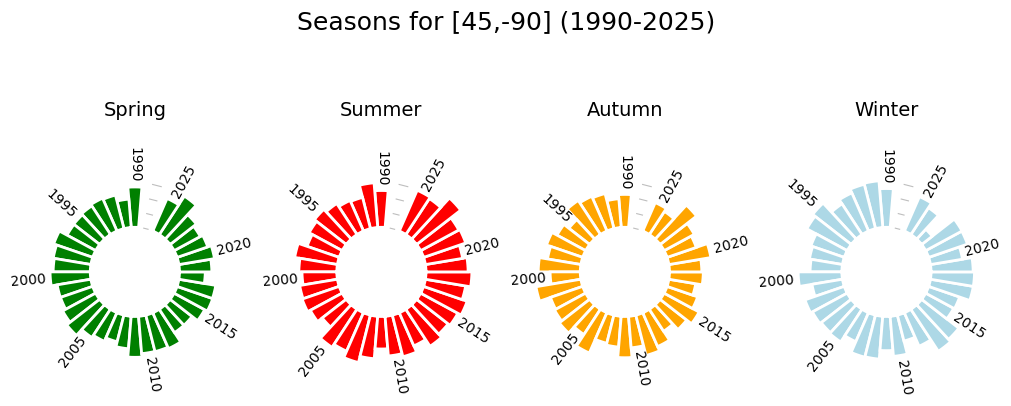

In [106]:
CircularSeasonPlots(45,-90)

In [107]:
# Toronto 43.6833	-79.6333
tor_lat = 43.6833
tor_lon = -79.6333

# Sydney
syd_lat = np.round(-33 - 52/60 - 4/3600, 3)
syd_lon = 151.25

# Vancouver
van_lat = 49.246
van_lon = -123.116

# Minneapolis
msp_lat = 45
msp_lon = -93.25

# Paris
par_lat = 48.7167
par_lon = 2.3842

#### Vancouver

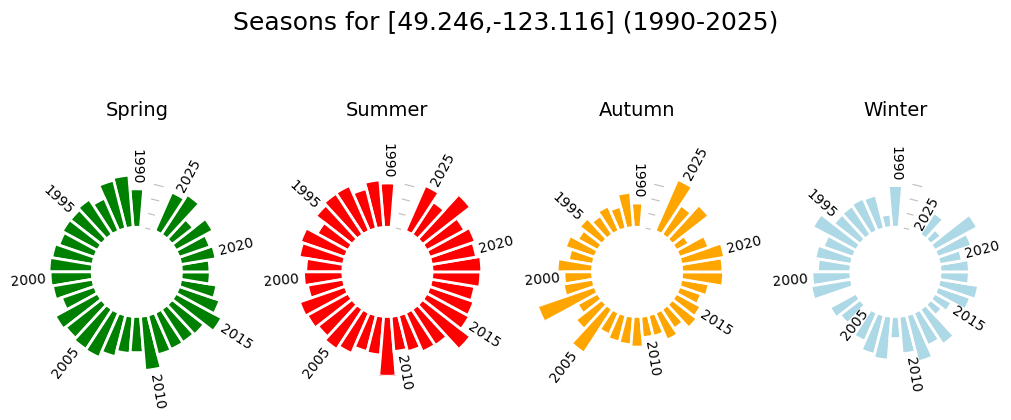

In [108]:
CircularSeasonPlots(van_lat,van_lon)

#### Sydney

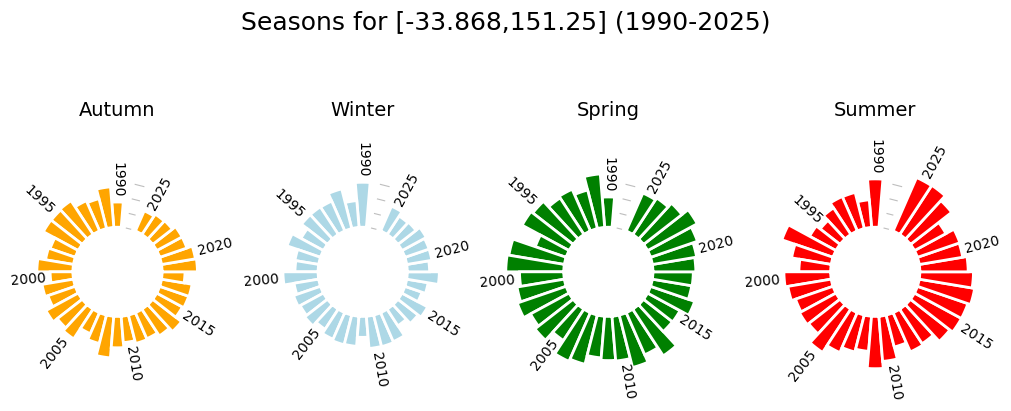

In [109]:
CircularSeasonPlots(syd_lat,syd_lon)

#### Minneapolis

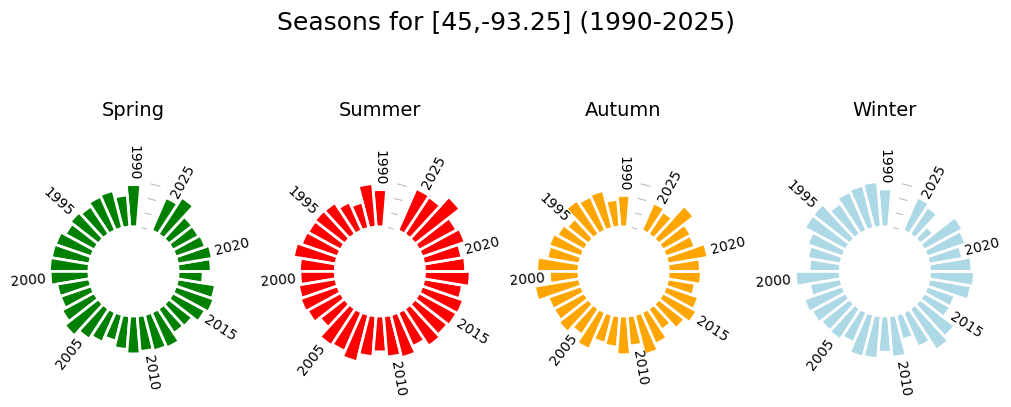

In [110]:
CircularSeasonPlots(msp_lat, msp_lon)

#### Paris

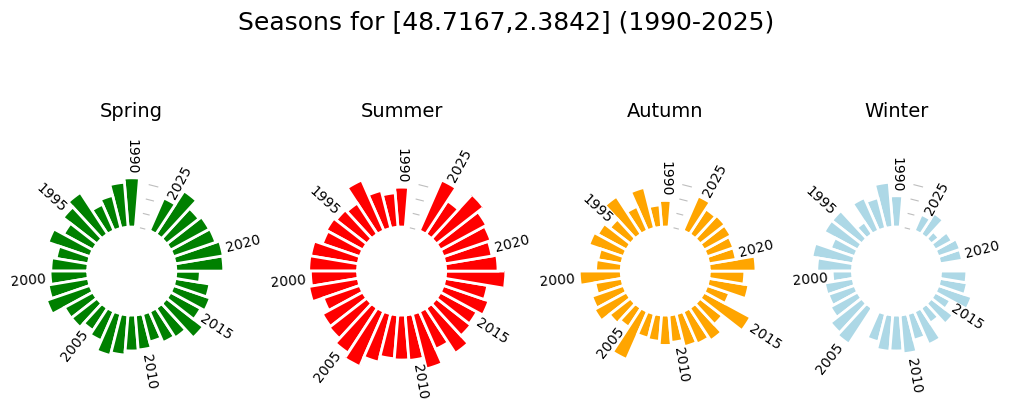

In [111]:
CircularSeasonPlots(par_lat, par_lon)

### Circular Barplots of Anomalies

In [ ]:
nh_land_anom_5Y

In [112]:
# create data for bar plot
# start at 1966
nh_land_anom_5Y_p = nh_land_anom_5Y.sel(time=slice('1966','2026'))

yrs = nh_land_anom_5Y_p.time.dt.year.values

# Build a dataset
df_anom = pd.DataFrame({
    "year": np.concatenate((yrs,yrs,yrs,yrs)),
    "value": np.concatenate((nh_land_anom_5Y_p.AutumnLength, nh_land_anom_5Y_p.WinterLength, nh_land_anom_5Y_p.SpringLength, nh_land_anom_5Y_p.SummerLength)),
    "group": ["Autumn"] * yrs.size + ["Winter"] * yrs.size + ["Spring"] * yrs.size + ["Summer"] * yrs.size
})

# Show 3 first rows
df_anom

,year,value,group
0,1966,-0.756422,Autumn
1,1971,0.535299,Autumn
2,1976,-1.140251,Autumn
3,1981,2.827214,Autumn
4,1986,-0.995497,Autumn
5,1991,-0.704449,Autumn
6,1996,-0.883538,Autumn
7,2001,-2.612693,Autumn
8,2006,0.885461,Autumn
9,2011,-1.080590,Autumn


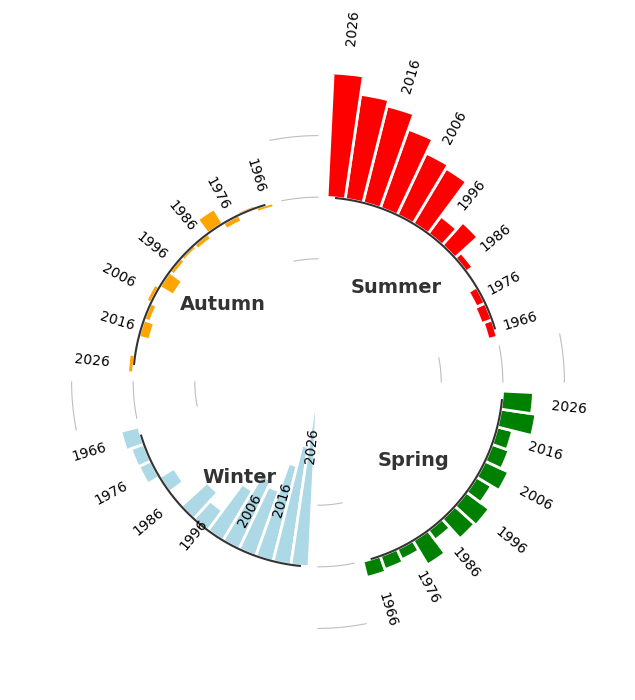

In [113]:
# All this part is like the code above
VALUES = df_anom["value"].values
LABELS = df_anom["year"].values
GROUP = df_anom["group"].values

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in df_anom.groupby("group")]

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

fig, ax = plt.subplots(figsize=(18, 8), subplot_kw={"projection": "polar"})
#plt.suptitle("NH Land Season Length 5Y Anomaly from 1961-1990 Mean\n\n")
#plt.title("\n")
ax.set_theta_offset(OFFSET)
ax.set_ylim(-30, 20)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

GROUPS_SIZE = [len(i[1]) for i in df_anom.groupby("group")]
COLORS = ["orange"]*13 + ["lightblue"]*13+ ["green"]*13 + ["red"]*13
#COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax, 2)

# Extra customization below here --------------------

# This iterates over the sizes of the groups adding reference
# lines and annotations.

offset = 0 
for group, size in zip(["Autumn", "Winter", "Spring", "Summer"], GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [0] * 50, color="#333333")
    
    # Add text to indicate group
    ax.text(
        np.mean(x1), -10, group, color="#333333", fontsize=14, 
        fontweight="bold", ha="center", va="center"
    )
    
    # Add reference lines at 10, 20, 30, and 40 %
    x2 = np.linspace(ANGLES[offset], ANGLES[offset + PAD - 1], num=50)
    ax.plot(x2, [-10] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [0] * 50, color="#bebebe", lw=0.8)
    ax.plot(x2, [10] * 50, color="#bebebe", lw=0.8)
    #ax.plot(x2, [20] * 50, color="#bebebe", lw=0.8)
    
    offset += size + PAD

### Barplots of anomalies and season lengths

Text(0, 0.5, 'Length [Days]')

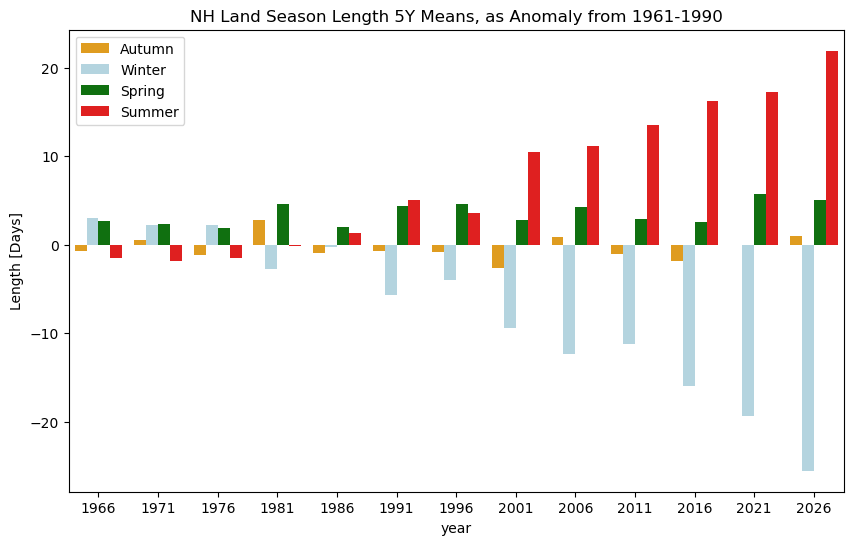

In [114]:
# got rid of legend title following https://stackoverflow.com/questions/51579215/remove-seaborn-lineplot-legend-title
plt.figure(figsize=(10,6))
sns.barplot(x="year", y="value", hue=df_anom["group"].to_list(), data=df_anom, palette=["orange","lightblue","green","red"])
plt.title("NH Land Season Length 5Y Means, as Anomaly from 1961-1990")
plt.ylabel("Length [Days]")

In [115]:
# data for summer vs winter (Sydney)
df_sum = df_an.query("(group == 'Summer')").drop('group', axis=1)
df_sum.rename(columns={'value':'Summer'}, inplace=True)
df_wint = df_an.query("(group == 'Winter')").drop('group',axis=1)
df_wint.rename(columns={'value':'Winter'}, inplace=True)
df_sumwint = pd.merge(df_sum,df_wint, on='year')
df_sumwint['diff'] = df_sumwint['Summer'] - df_sumwint['Winter']
df_sumwint#.info()

,year,Summer,Winter,diff
0,1990,32.485876,30.225989,2.259887
1,1991,18.579235,18.032787,0.546448
2,1992,25.068120,27.520436,-2.452316
3,1993,25.280899,21.910112,3.370787
4,1994,21.329640,22.160665,-0.831025
5,1995,16.939891,22.131148,-5.191257
6,1996,20.199501,17.206983,2.992519
7,1997,36.363636,23.796791,12.566845
8,1998,26.988636,16.193182,10.795455
9,1999,21.315789,15.526316,5.789474


Text(0, 0.5, "% of 'year'")

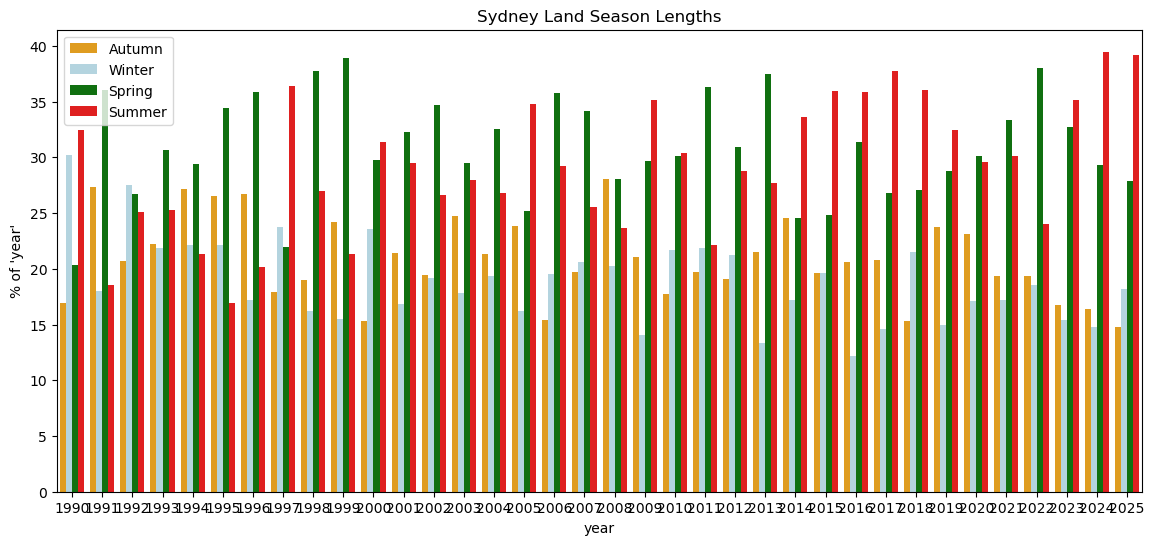

In [116]:
plt.figure(figsize=(14,6))
sns.barplot(x="year", y="value", hue=df_an["group"].to_list(), data=df_an, palette=["orange","lightblue","green","red"])
plt.title("Sydney Land Season Lengths")
plt.ylabel("% of 'year'")

Text(0, 0.5, "% of 'year'")

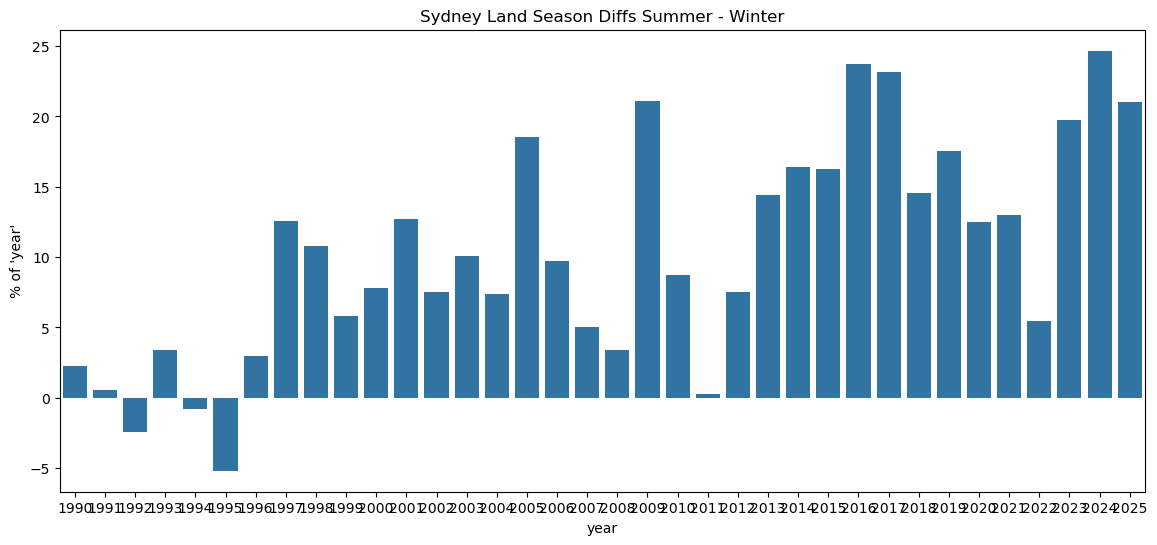

In [117]:
plt.figure(figsize=(14,6))
sns.barplot(x="year", y="diff", data=df_sumwint)
plt.title("Sydney Land Season Diffs Summer - Winter")
plt.ylabel("% of 'year'")

# *** Make time series plots like for Syd and Van but for mean climatology to see how spring and autumn change and profile shifts

#### similar to fig 6 from ERL paper but for NH/SH land: Climatologies for 1961–1990 and (1990-?) 1996–2025 smoothed with a 30 d rolling-mean

In [312]:
filepath = "../../../../Data/ERA5-global/Analysis/New-Fourier/1961-1990_DOYClimatologyNH.nc"
ds_base_clim_nh = xr.open_dataset(filepath)
ds_base_clim_nh = ds_base_clim_nh.drop_vars(['realization'])
ds_base_clim_nh                   

<xarray.Dataset> Size: 393MB
Dimensions:    (dayofyear: 365, lat: 187, lon: 1440)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.25 69.5 69.75 70.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    DOYClim    (dayofyear, lat, lon) float32 393MB ...

In [313]:
# add lsm for filtering
ds_base_clim_nh = ds_base_clim_nh.merge(ds_seasons.sel(lat=slice(nh_min, nh_max)).lsm)
ds_base_clim_nh

<xarray.Dataset> Size: 395MB
Dimensions:    (dayofyear: 365, lat: 187, lon: 1440)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.25 69.5 69.75 70.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    DOYClim    (dayofyear, lat, lon) float32 393MB ...
    lsm        (lat, lon) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.006974 0.01392

In [314]:
ds_base_clim_land_nh = ds_base_clim_nh.where((ds_base_clim.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])
ds_base_clim_land_nh

<xarray.Dataset> Size: 6kB
Dimensions:    (dayofyear: 365)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    DOYClim    (dayofyear) float64 3kB 264.3 264.1 264.0 ... 264.4 264.3 264.3
    lsm        float64 8B 0.9671

In [264]:
# get mean 75th and 25th percentile temps a.k.a. thresholds for summer and winter
file_path_25 = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc'
file_path_75 = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_25 = xr.open_dataarray(file_path_25)
c_75 = xr.open_dataarray(file_path_75)

In [265]:
c_25

<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
[1038240 values with dtype=float64]
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B ...
Attributes:
    long_name:  25th percentile 2m Temperature for the data across available ...
    units:      K

In [339]:
# mean NH midlat c25 and c75
nh_c_25 = c_25.sel(lat=slice(nh_min, nh_max)).where((ds_base_clim.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])
nh_c_75 = c_75.sel(lat=slice(nh_min, nh_max)).where((ds_base_clim.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])
nh_c_25

<xarray.DataArray 't2m' ()> Size: 8B
array(269.50907424)
Coordinates:
    quantile  float64 8B 0.25

Text(0.5, 1.0, 'NH Land Climatology 1961-1990')

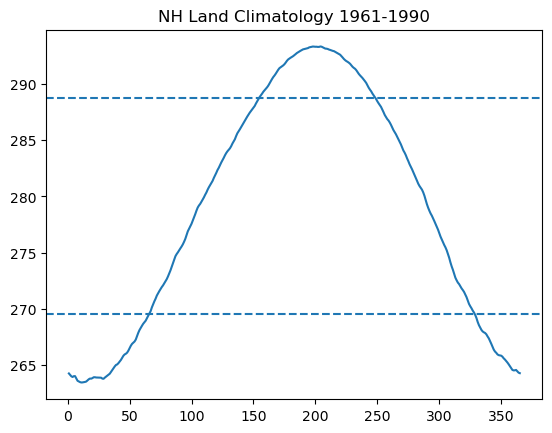

In [340]:
plt.plot(ds_base_clim_land_nh.dayofyear, ds_base_clim_land.DOYClim)
plt.axhline(nh_c_25, linestyle="dashed")
plt.axhline(nh_c_75, linestyle="dashed")
plt.title("NH Land Climatology 1961-1990")

## load in all of the analysis years, global t2m data, so we can add 1996-2025 climatology to plot

In [341]:
%%time

# takes 5 sec to load dask array
input_path = '../../../../Data/ERA5-global/Analysis/*/download_daily_mean_2m_temperature_*.nc'
ds_an = xr.open_mfdataset(input_path, coords='minimal')


CPU times: user 1.93 s, sys: 1.35 s, total: 3.28 s
Wall time: 3.76 s


In [342]:
ds_an = ds_an.drop_vars(['realization'])
ds_an

<xarray.Dataset> Size: 55GB
Dimensions:  (time: 13330, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 107kB 1990-01-01 1990-01-02 ... 2026-06-30
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m      (time, lat, lon) float32 55GB dask.array<chunksize=(31, 361, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-07T04:55 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

## Drop leap years so grouping by DOY works across years

In [343]:
%%time
ds_an = ds_an.convert_calendar('noleap', use_cftime=None)

# alows us to slice years
ds_an = ds_an.convert_calendar('365_day')

ds_an

CPU times: user 88.8 ms, sys: 10.7 ms, total: 99.5 ms
Wall time: 100 ms


<xarray.Dataset> Size: 55GB
Dimensions:  (time: 13321, lat: 721, lon: 1440)
Coordinates:
  * time     (time) object 107kB 1990-01-01 00:00:00 ... 2026-06-30 00:00:00
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m      (time, lat, lon) float32 55GB dask.array<chunksize=(27, 361, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-07T04:55 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

### Reduce to 1996-2025 (most recent 30 yrs), NH midlatitudes, climatology

In [344]:
ds_an_nh = ds_an.sel(time=slice('1996','2025'), lat=slice(nh_min, nh_max))
ds_an_nh = ds_an_nh.merge(ds_seasons.sel(lat=slice(nh_min, nh_max)).lsm)
ds_an_land_nh = ds_an_nh.where((ds_an_nh.lsm > 0.5))
ds_an_clim_land_nh = ds_an_land_nh.t2m.groupby("time.dayofyear").mean()

ds_an_clim_land_nh

<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<stack, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 720), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.25 69.5 69.75 70.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

### finally lat weighted NH clim 1996-2025

In [345]:
ds_an_clim_land_wgt_nh = ds_an_clim_land_nh.weighted(weights).mean(dim=['lat','lon'])
ds_an_clim_land_wgt_nh.load()

<xarray.DataArray 't2m' (dayofyear: 365)> Size: 3kB
array([265.54822446, 265.48573697, 265.4342549 , 265.35840748,
       265.2819145 , 265.22685566, 265.13207191, 265.07012419,
       265.10623446, 265.10920628, 265.08022546, 265.05332673,
       265.05490397, 265.09874837, 265.14465288, 265.18467844,
       265.1911167 , 265.200055  , 265.15772395, 265.00763529,
       264.94337396, 264.90734568, 264.95150153, 265.03294474,
       265.08381045, 265.13667116, 265.24568482, 265.34112048,
       265.42051638, 265.54044444, 265.69374628, 265.79563771,
       265.83297494, 265.88369464, 265.96698894, 266.12971504,
       266.2480447 , 266.34353165, 266.43633913, 266.50279734,
       266.63624246, 266.76695248, 266.92388998, 267.11593461,
       267.2611627 , 267.31480824, 267.41386252, 267.5116609 ,
       267.67584441, 267.87689266, 268.12084575, 268.33707186,
       268.5332543 , 268.73007712, 268.9202641 , 269.07177041,
       269.20284664, 269.38120149, 269.5676354 , 269.85149607,
       270.08448373, 270.31832665, 270.59476363, 270.77726257,
       270.89158899, 271.10821058, 271.36162894, 271.59262718,
       271.87559455, 272.14505893, 272.38443104, 272.63217721,
       272.89266117, 273.0704283 , 273.21412983, 273.37382351,
       273.55720765, 273.73088087, 273.93471863, 274.17671495,
...
       280.78601811, 280.57601734, 280.34181097, 280.11723989,
       279.89393299, 279.58017093, 279.30468949, 279.10089143,
       278.90085148, 278.66303526, 278.39135164, 278.07581652,
       277.833019  , 277.59735118, 277.40640762, 277.15303804,
       276.87395119, 276.56933607, 276.31159832, 276.09992382,
       275.85058345, 275.50097827, 275.13052113, 274.80123952,
       274.49053498, 274.16066447, 273.83041019, 273.54866788,
       273.32127494, 273.12135258, 272.85492358, 272.55712544,
       272.30466239, 272.03292091, 271.78605442, 271.54210722,
       271.24539966, 270.99206952, 270.73936106, 270.46252255,
       270.23361594, 270.02843146, 269.80104548, 269.52364089,
       269.28612102, 269.08059945, 268.90086993, 268.80267286,
       268.70919734, 268.53618817, 268.39551906, 268.2292699 ,
       268.0170228 , 267.8513919 , 267.77209013, 267.64118532,
       267.4398475 , 267.28128131, 267.23396966, 267.19743054,
       267.02718193, 266.93184793, 266.83353587, 266.69750306,
       266.62630094, 266.54445961, 266.4466002 , 266.35084436,
       266.26232787, 266.19361624, 266.11687734, 266.0590144 ,
       266.08850239, 266.07961819, 265.95334769, 265.83071622,
       265.69954823])
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

CPU times: user 5.37 ms, sys: 4.76 ms, total: 10.1 ms
Wall time: 14.5 ms


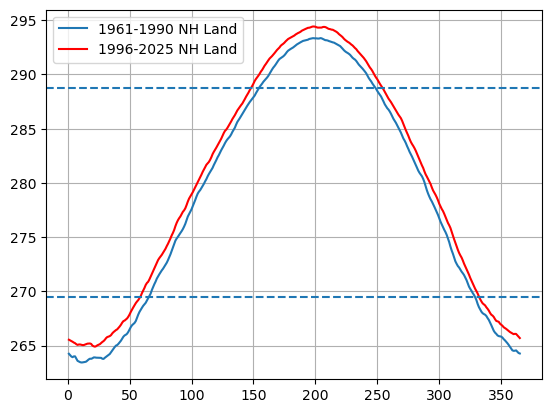

In [346]:
%%time

# add to plot
plt.plot(ds_base_clim_land_nh.dayofyear, ds_base_clim_land_nh.DOYClim, label="1961-1990 NH Land")
plt.plot(ds_an_clim_land_wgt_nh.dayofyear, ds_an_clim_land_wgt_nh, color="red", label="1996-2025 NH Land")
plt.axhline(nh_c_25, linestyle="dashed")
plt.axhline(nh_c_75, linestyle="dashed")
plt.legend()
plt.grid()

## *** maybe need to try shorter time windows to see spring getting longer?

In [347]:
%%time
ds_an_clim_land_1991_2000_nh = ds_an_land_nh.sel(time=slice('1991','2000')).t2m.groupby("time.dayofyear").mean()
ds_an_clim_land_2011_2020_nh = ds_an_land_nh.sel(time=slice('2011','2020')).t2m.groupby("time.dayofyear").mean()
ds_an_clim_land_2021_2025_nh = ds_an_land_nh.sel(time=slice('2021','2025')).t2m.groupby("time.dayofyear").mean()

# weighted mean climatology for NH midlats over each period
ds_an_clim_land_wgt_1991_2000_nh = ds_an_clim_land_1991_2000_nh.weighted(weights).mean(dim=['lat','lon'])
ds_an_clim_land_wgt_2011_2020_nh = ds_an_clim_land_2011_2020_nh.weighted(weights).mean(dim=['lat','lon'])
ds_an_clim_land_wgt_2021_2025_nh = ds_an_clim_land_2021_2025_nh.weighted(weights).mean(dim=['lat','lon'])
#ds_an_clim_land_wgt_1991_2000_nh.load(), ds_an_clim_land_wgt_2011_2020_nh.load(), ds_an_clim_land_wgt_2021_2025_nh.load()

CPU times: user 1.42 s, sys: 140 ms, total: 1.56 s
Wall time: 1.66 s


CPU times: user 6.01 s, sys: 4.26 s, total: 10.3 s
Wall time: 5.56 s


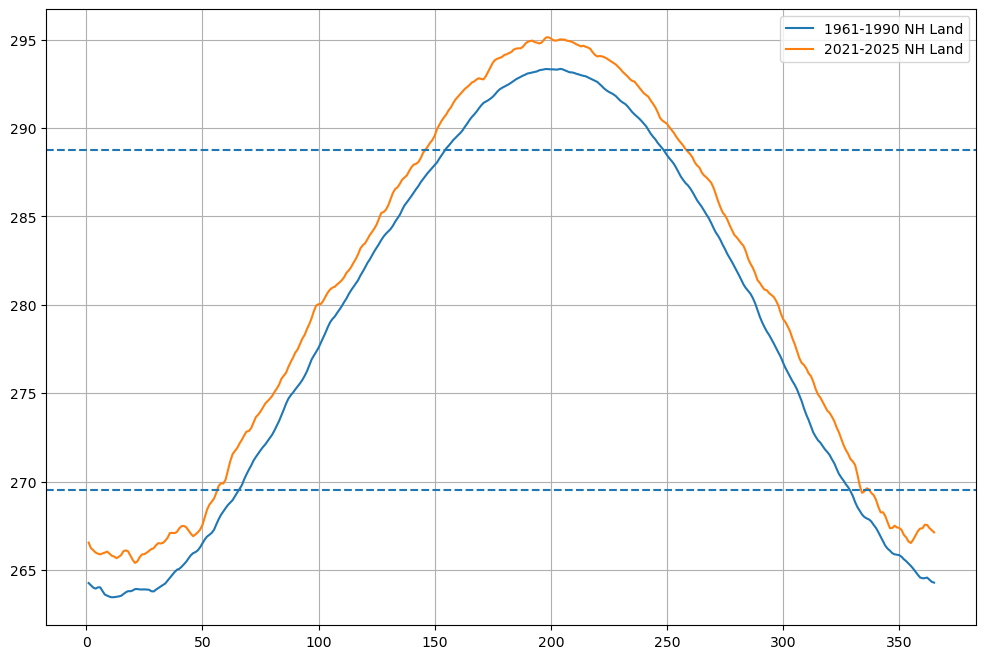

In [348]:
%%time
# plot
# add to plot
plt.figure(figsize=(12,8))
plt.plot(ds_base_clim_land_nh.dayofyear, ds_base_clim_land_nh.DOYClim, label="1961-1990 NH Land")
#plt.plot(ds_an_clim_land_wgt_1991_2000.dayofyear, ds_an_clim_land_wgt_1991_2000, label="1991-2000 NH Land")
#plt.plot(ds_an_clim_land_wgt_2011_2020.dayofyear, ds_an_clim_land_wgt_2011_2020, label="2011-2020 NH Land")
plt.plot(ds_an_clim_land_wgt_2021_2025_nh.dayofyear, ds_an_clim_land_wgt_2021_2025_nh, label="2021-2025 NH Land")
plt.axhline(nh_c_25, linestyle="dashed")
plt.axhline(nh_c_75, linestyle="dashed")
plt.legend()
plt.grid()

#### NH sure looks like a shift upward, which does explain why spring and autumn length are not changing much but winter and summer very much are

In [323]:
sh_min, sh_max

(-23.5, -70)

## SH 1996-2025 (most recent 30 yrs), midlatitudes, land climatology

### generate SH baseline (1961-1990) climatology since we don't have that already

In [334]:
%%time

# takes 5 sec to load dask array
input_path = '../../../../Data/ERA5-global/Baseline/*/download_daily_mean_2m_temperature_*.nc'
ds_baseline = xr.open_mfdataset(input_path, coords='minimal')
ds_baseline


CPU times: user 1.64 s, sys: 1.14 s, total: 2.78 s
Wall time: 3.03 s


<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    realization  int64 8B 0
Data variables:
    t2m          (time, lat, lon) float32 46GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [335]:
# add lsm and create climatology
ds_baseline = ds_baseline.merge(ds_seasons.lsm).drop_vars(['realization'])

ds_baseline = ds_baseline.convert_calendar('noleap', use_cftime=None)

# alows us to slice years
ds_baseline = ds_baseline.convert_calendar('365_day')

ds_baseline

<xarray.Dataset> Size: 45GB
Dimensions:  (time: 10950, lat: 721, lon: 1440)
Coordinates:
  * time     (time) object 88kB 1961-01-01 00:00:00 ... 1990-12-31 00:00:00
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m      (time, lat, lon) float32 45GB dask.array<chunksize=(30, 721, 1440), meta=np.ndarray>
    lsm      (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [336]:
ds_baseline_sh = ds_baseline.sel(lat=slice(sh_max, sh_min))
ds_baseline_land_sh = ds_baseline_sh.where(ds_baseline_sh.lsm > 0.5)
ds_baseline_clim_land_sh = ds_baseline_land_sh.t2m.groupby("time.dayofyear").mean()
ds_baseline_clim_land_sh



<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<stack, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB -70.0 -69.75 -69.5 ... -24.0 -23.75 -23.5
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

In [354]:

ds_an_sh = ds_an.sel(time=slice('1996','2025'), lat=slice(sh_max, sh_min))
ds_an_sh = ds_an_sh.merge(ds_seasons.sel(lat=slice(sh_max, sh_min)).lsm)
ds_an_land_sh = ds_an_sh.where((ds_an_sh.lsm > 0.5))
ds_an_clim_land_sh = ds_an_land_sh.t2m.groupby("time.dayofyear").mean()

ds_an_clim_land_sh

<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<stack, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 720), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB -70.0 -69.75 -69.5 ... -24.0 -23.75 -23.5
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

### finally lat weighted SH land clim 1996-2025 and 1961-1990

In [352]:
# thresholds
sh_c_25 = c_25.sel(lat=slice(sh_max, sh_min)).where((ds_baseline.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])
sh_c_75 = c_75.sel(lat=slice(sh_max, sh_min)).where((ds_baseline.lsm > 0.5)).weighted(weights).mean(dim=['lat','lon'])


In [355]:
%%time

ds_an_clim_land_wgt_sh = ds_an_clim_land_sh.weighted(weights).mean(dim=['lat','lon'])
ds_baseline_clim_land_wgt_sh = ds_baseline_clim_land_sh.weighted(weights).mean(dim=['lat','lon'])
ds_an_clim_land_wgt_sh.load(), ds_baseline_clim_land_wgt_sh.load()

(<xarray.DataArray 't2m' (dayofyear: 365)> Size: 3kB
 array([292.01888149, 292.00044069, 292.01409459, 291.92516224,
        291.93246275, 291.92355325, 291.83300299, 291.87581057,
        292.04436994, 292.15262191, 292.12121917, 292.2355045 ,
        292.11101481, 292.05189921, 292.15129241, 292.09157582,
        291.95817738, 291.90653359, 292.04032404, 292.05764195,
        292.11633901, 292.21017876, 292.21773615, 292.0757495 ,
        291.99914493, 291.93762371, 291.84087376, 291.89797892,
        291.92448818, 291.74343491, 291.48010037, 291.31179522,
        291.15299893, 291.27963549, 291.2992284 , 291.26877867,
        291.35960811, 291.34543003, 291.22791048, 291.14042554,
        291.02623301, 290.95485695, 290.84202224, 290.74639088,
        290.87690278, 290.9542895 , 290.95508719, 290.9563277 ,
        290.77798584, 290.55601252, 290.43547168, 290.44540095,
        290.46487843, 290.39135616, 290.42907792, 290.35247109,
        290.27461006, 290.24643409, 289.99100544, 2

CPU times: user 12.5 ms, sys: 15.5 ms, total: 27.9 ms
Wall time: 30 ms


Text(0.5, 1.0, 'SH Land Climatologies')

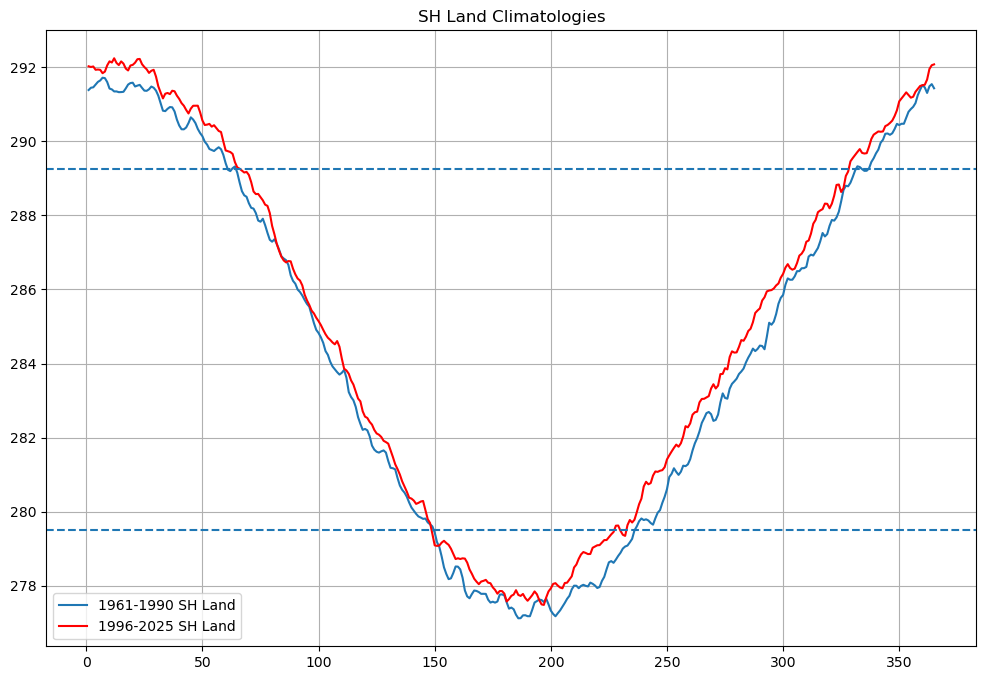

In [358]:
%%time

# takes 60 sec unless I pre-load the data

# add to plot
plt.figure(figsize=(12,8))
plt.plot(ds_baseline_clim_land_wgt_sh.dayofyear, ds_baseline_clim_land_wgt_sh, label="1961-1990 SH Land")
plt.plot(ds_an_clim_land_wgt_sh.dayofyear, ds_an_clim_land_wgt_sh, color="red", label="1996-2025 SH Land")
plt.axhline(sh_c_25, linestyle="dashed")
plt.axhline(sh_c_75, linestyle="dashed")
plt.legend()
plt.grid()
plt.title("SH Land Climatologies")

### SH land shifts up and left - maybe enough to explain change in spring length?

## same but for NH Midlat Ocean

In [359]:
ds_base_clim_ocean_nh = ds_base_clim_nh.where((ds_base_clim.lsm <= 0.5)).weighted(weights).mean(dim=['lat','lon'])
ds_base_clim_ocean_nh

<xarray.Dataset> Size: 6kB
Dimensions:    (dayofyear: 365)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    DOYClim    (dayofyear) float64 3kB 282.7 282.7 282.6 ... 282.9 282.9 282.8
    lsm        float64 8B 0.01637

In [360]:
# mean NH midlat c25 and c75
nh_c_25_ocean = c_25.sel(lat=slice(nh_min, nh_max)).where((ds_base_clim.lsm <= 0.5)).weighted(weights).mean(dim=['lat','lon'])
nh_c_75_ocean = c_75.sel(lat=slice(nh_min, nh_max)).where((ds_base_clim.lsm <= 0.5)).weighted(weights).mean(dim=['lat','lon'])
nh_c_25_ocean

<xarray.DataArray 't2m' ()> Size: 8B
array(283.29235929)
Coordinates:
    quantile  float64 8B 0.25

Text(0.5, 1.0, 'NH Ocean Climatology 1961-1990')

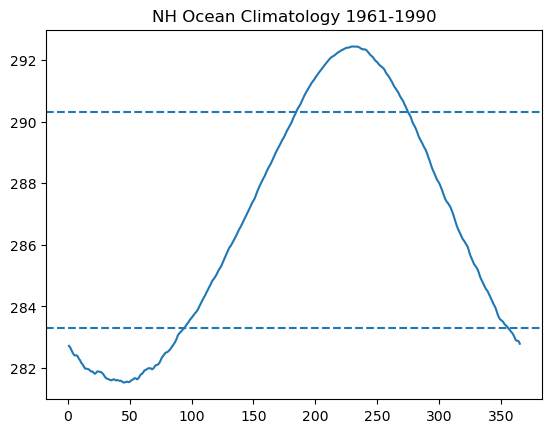

In [365]:
plt.plot(ds_base_clim_ocean_nh.dayofyear, ds_base_clim_ocean_nh.DOYClim)
plt.axhline(nh_c_25_ocean, linestyle="dashed")
plt.axhline(nh_c_75_ocean, linestyle="dashed")
plt.title("NH Ocean Climatology 1961-1990")

### Reduce to 1996-2025 (most recent 30 yrs), NH midlatitudes, climatology

In [366]:
ds_an_nh = ds_an.sel(time=slice('1996','2025'), lat=slice(nh_min, nh_max))
ds_an_nh = ds_an_nh.merge(ds_seasons.sel(lat=slice(nh_min, nh_max)).lsm)
ds_an_ocean_nh = ds_an_nh.where((ds_an_nh.lsm <= 0.5))
ds_an_clim_ocean_nh = ds_an_ocean_nh.t2m.groupby("time.dayofyear").mean()

ds_an_clim_ocean_nh

<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<stack, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 720), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.25 69.5 69.75 70.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

### finally lat weighted NH ocean clim 1996-2025

In [368]:
ds_an_clim_ocean_wgt_nh = ds_an_clim_ocean_nh.weighted(weights).mean(dim=['lat','lon'])
ds_an_clim_ocean_wgt_nh.load()

<xarray.DataArray 't2m' (dayofyear: 365)> Size: 3kB
array([283.36647532, 283.30666291, 283.25263609, 283.21898649,
       283.20330239, 283.1383908 , 283.05549992, 282.98412167,
       282.96383338, 282.93057896, 282.89588905, 282.90044491,
       282.86695003, 282.79788803, 282.71146135, 282.62173982,
       282.61222591, 282.60600775, 282.63079273, 282.64504669,
       282.57787071, 282.48067147, 282.39336139, 282.34983035,
       282.35358721, 282.33387881, 282.33813933, 282.34037574,
       282.33076408, 282.29853938, 282.28501895, 282.27595693,
       282.25789796, 282.26417607, 282.2614089 , 282.26220414,
       282.252641  , 282.22962693, 282.18761479, 282.19308689,
       282.22352016, 282.24938315, 282.2318831 , 282.2344965 ,
       282.23603574, 282.25830866, 282.27458493, 282.29014673,
       282.26840652, 282.2733293 , 282.27409642, 282.26076859,
       282.29415176, 282.33442112, 282.36694312, 282.38784148,
       282.39311458, 282.37600794, 282.39207505, 282.4213817 ,
       282.47817292, 282.53629233, 282.5245503 , 282.52917342,
       282.53048201, 282.53739309, 282.57454977, 282.61121371,
       282.64668132, 282.66629965, 282.72335641, 282.76108815,
       282.78329595, 282.85870886, 282.92479406, 282.98549384,
       283.03154604, 283.08229034, 283.08583652, 283.14933118,
...
       289.84488488, 289.74834242, 289.63503635, 289.51763012,
       289.44899899, 289.36157016, 289.24980979, 289.13052874,
       289.02696943, 288.93427232, 288.84374785, 288.76013148,
       288.69678546, 288.6061193 , 288.50685081, 288.41725059,
       288.34638509, 288.25577566, 288.12928372, 288.02059989,
       287.94373993, 287.84817665, 287.74311845, 287.64641305,
       287.55079218, 287.4693097 , 287.39873213, 287.29387273,
       287.20051344, 287.08945438, 286.98856975, 286.87894922,
       286.77855945, 286.65341546, 286.5486878 , 286.49575409,
       286.45073554, 286.33323503, 286.2233495 , 286.15871012,
       286.06316371, 285.9930666 , 285.92795439, 285.80250562,
       285.68373171, 285.59506546, 285.52041219, 285.42132156,
       285.34943851, 285.28454436, 285.22411454, 285.16837008,
       285.08073596, 284.98302788, 284.89207109, 284.81918278,
       284.73761507, 284.63338577, 284.54304787, 284.48357869,
       284.41982229, 284.37279927, 284.30211078, 284.23861438,
       284.17314194, 284.1052352 , 284.0106513 , 283.94181991,
       283.87863406, 283.81665417, 283.78356789, 283.69641073,
       283.62558571, 283.59568975, 283.58985724, 283.54323758,
       283.46519629])
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

CPU times: user 12.2 ms, sys: 3.68 ms, total: 15.9 ms
Wall time: 15.3 ms


Text(0.5, 1.0, 'NH Midlat Ocean Climatologies')

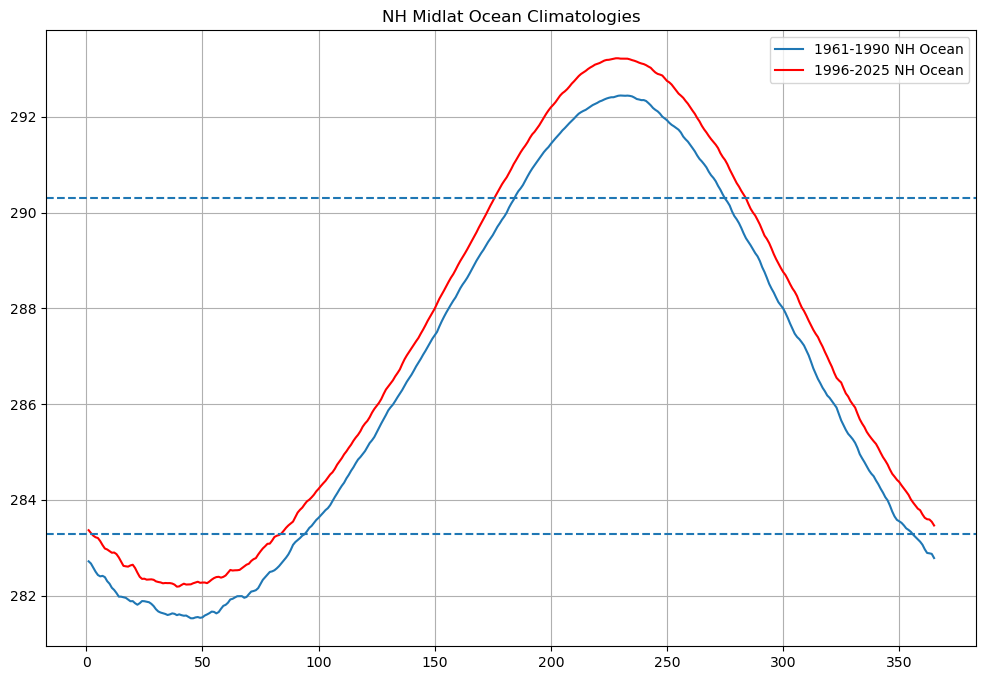

In [370]:
%%time

# add to plot
plt.figure(figsize=(12,8))


plt.plot(ds_base_clim_ocean_nh.dayofyear, ds_base_clim_ocean_nh.DOYClim, label="1961-1990 NH Ocean")
plt.plot(ds_an_clim_ocean_wgt_nh.dayofyear, ds_an_clim_ocean_wgt_nh, color="red", label="1996-2025 NH Ocean")
plt.axhline(nh_c_25_ocean, linestyle="dashed")
plt.axhline(nh_c_75_ocean, linestyle="dashed")
plt.legend()
plt.grid()
plt.title("NH Midlat Ocean Climatologies")

# Really amazing how it is simply an upward shift